# Contextual Downstream Evaluation

This notebook evaluates Unicorn's **contextual representations** — the transformer-level outputs that depend on lineup context. It complements `evaluate_embeddings.ipynb` (which covers static embedding analysis).

**Key distinction:** Static embeddings give each player a fixed vector. Contextual representations mean LeBron-next-to-Kyrie != LeBron-next-to-Westbrook. The analyses here are what differentiate Unicorn from simpler embedding methods.

**Sections:**
1. Setup & Model Loading
2. Replacement Value Baseline & Player Impact Quantification
3. Lineup Optimization, Defensive Matchups & Counterfactuals
4. Superstar Ecosystem Modeling
5. Lineup Chemistry / System Effects
6. Attention Weight Analysis
7. Role Versatility Detection
8. Aging Curves & Skill Evolution

## Section 1: Setup & Model Loading

In [1]:
import sys, os, csv

# Run from project root so all relative paths work
PROJECT_ROOT = os.path.expanduser("~/Desktop/unicorn")
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
print(f"Working directory: {os.getcwd()}")
print(f"Files present: {os.path.exists('evaluate.py')}, {os.path.exists('joint_v32_checkpoint_latest.pt')}")

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from collections import defaultdict
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

# --- Load model ---
from evaluate import load_model
from nba_dataset import PossessionDataset, OUTCOME_NAMES, NUM_OUTCOMES, OUTCOME_VOCAB
from prior_year_init import build_ps_to_base_tensor, build_base_player_mapping
from game_outcome import load_embeddings

CKPT_PATH = "joint_v32_checkpoint_latest.pt"
model, ckpt = load_model(CKPT_PATH, "transformer", device)
model.eval()
print(f"Architecture: {ckpt.get('architecture', 'unknown')}")
print(f"Epoch: {ckpt.get('last_epoch', '?')}")

# --- Load test dataset ---
test_ds = PossessionDataset("possessions.parquet", split="test", shuffle_players=False)
print(f"Test possessions: {len(test_ds):,}")

# --- Name lookups ---
lu = pd.read_csv("player_season_lookup.csv")
name_map = {}
with open("bbref_name_mapping.csv") as f:
    reader = csv.DictReader(f)
    for row in reader:
        name_map[row["bbref_id"]] = row["display_name"]

def display_name(bbref_id):
    return name_map.get(bbref_id, bbref_id)

lu["display"] = lu["player"].map(display_name) + " (" + lu["season"].astype(str) + ")"
id_to_name = lu.set_index("player_season_id")["display"].to_dict()
id_to_player = lu.set_index("player_season_id")["player"].to_dict()
id_to_season = lu.set_index("player_season_id")["season"].to_dict()

# Reverse lookup: (bbref, season) -> player_season_id
name_season_to_id = {}
for _, row in lu.iterrows():
    name_season_to_id[(row["player"], int(row["season"]))] = int(row["player_season_id"])

def ps_id(bbref, season):
    """Convenience: get player_season_id from bbref + season."""
    return name_season_to_id.get((bbref, season))

# Base player mapping
ps_to_base_map, num_base = build_base_player_mapping()
ps_to_base_tensor, _ = build_ps_to_base_tensor(len(lu))

base_to_player = {}
for _, row in lu.iterrows():
    ps_id_val = int(row["player_season_id"])
    if ps_id_val in ps_to_base_map:
        base_id = ps_to_base_map[ps_id_val]
        if base_id not in base_to_player:
            base_to_player[base_id] = row["player"]

# Outcome names in order
outcome_names = [OUTCOME_NAMES[i] for i in range(NUM_OUTCOMES)]
print(f"Outcomes: {outcome_names}")
print(f"Base players: {num_base:,}")
print(f"Player-seasons: {len(lu):,}")

Working directory: /Users/nbrown1/Desktop/unicorn
Files present: True, True
Device: mps


/Users/nbrown1/Desktop/unicorn/.unicorn/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Architecture: v3.2_distributional
Epoch: 25
Test possessions: 544,745
Outcomes: ['made_3pt', 'missed_3pt', 'made_2pt_close', 'made_2pt_mid', 'missed_2pt_close', 'missed_2pt_mid', 'FT', 'turnover_live', 'turnover_dead']
Base players: 2,310
Player-seasons: 12,821


In [2]:
# --- Helper functions ---

# Approximate expected-points value per outcome class
# Positive = good for offense, negative = bad for offense
VALUE_WEIGHTS = torch.tensor([
    3.0,   # made_3pt
    0.0,   # missed_3pt (neutral — shot attempt, possible OREB)
    2.0,   # made_2pt_close
    2.0,   # made_2pt_mid
   -0.2,   # missed_2pt_close (OREB chance)
   -0.3,   # missed_2pt_mid
    1.5,   # FT (avg ~1.5 pts from FT sequences)
   -1.0,   # turnover_live (fast break)
   -0.5,   # turnover_dead
], dtype=torch.float32).to(device)

TEAM_IDS = torch.tensor([0,0,0,0,0,1,1,1,1,1], dtype=torch.long, device=device)

@torch.no_grad()
def predict_lineup(players_10, state_3):
    """Run model on a single lineup. Returns (probs [9], off_attn [5])."""
    pl = torch.tensor(players_10, dtype=torch.long, device=device).unsqueeze(0)
    st = torch.tensor(state_3, dtype=torch.float32, device=device).unsqueeze(0)
    tm = TEAM_IDS.unsqueeze(0)
    logits, attn = model.forward_finetune(pl, st, tm)
    probs = torch.softmax(logits, dim=1)
    return probs.squeeze(0).cpu(), attn.squeeze(0).cpu()

@torch.no_grad()
def predict_batch(players_batch, state_batch):
    """Run model on a batch. Returns (probs [B,9], attn [B,5])."""
    pl = torch.as_tensor(players_batch, dtype=torch.long, device=device)
    st = torch.as_tensor(state_batch, dtype=torch.float32, device=device)
    B = pl.shape[0]
    tm = TEAM_IDS.unsqueeze(0).expand(B, -1)
    logits, attn = model.forward_finetune(pl, st, tm)
    probs = torch.softmax(logits, dim=1)
    return probs.cpu(), attn.cpu()

def favorability(probs):
    """Scalar lineup quality score from outcome distribution."""
    return (probs * VALUE_WEIGHTS.cpu()).sum(dim=-1)

# Neutral game state: period 2, score tied, 1800s remaining
# Normalized: time/3600, score_diff/20, period/10
NEUTRAL_STATE = [1800/3600, 0/20, 2/10]

# Find replacement-level player (base embedding closest to centroid)
with torch.no_grad():
    base_emb = model.base_player_emb.weight.detach().cpu()
    centroid = base_emb.mean(dim=0)
    replacement_base_id = F.cosine_similarity(base_emb, centroid.unsqueeze(0)).argmax().item()

# Find a player-season ID that maps to this base player (pick one from test era)
replacement_ps_ids = [ps for ps, base in ps_to_base_map.items()
                      if base == replacement_base_id]
# Prefer a test-era season
replacement_ps_id = replacement_ps_ids[0]
for ps in replacement_ps_ids:
    if id_to_season.get(ps, 0) >= 2021:
        replacement_ps_id = ps
        break

repl_name = id_to_name.get(replacement_ps_id, f"ID_{replacement_ps_id}")
print(f"Replacement-level player: {repl_name} (base_id={replacement_base_id})")
print(f"Neutral state: {NEUTRAL_STATE}")

# Sanity check: run one prediction
test_players = test_ds.players[0]
test_state = test_ds.state[0]
probs, attn = predict_lineup(test_players, test_state)
print(f"\nSanity check — first test possession:")
print(f"  Players: {[id_to_name.get(p, p) for p in test_players[:5]]}")
print(f"  Probs: {dict(zip(outcome_names, probs.numpy().round(3)))}")
print(f"  Favorability: {favorability(probs).item():.4f}")
print(f"  Off attention: {attn.numpy().round(3)}")

Replacement-level player: Juwan Morgan (2022) (base_id=1456)
Neutral state: [0.5, 0.0, 0.2]

Sanity check — first test possession:
  Players: ['Javonte Green (2021)', 'Tremont Waters (2021)', 'Jayson Tatum (2021)', 'Brad Wanamaker (2021)', 'Daniel Theis (2021)']
  Probs: {'made_3pt': np.float32(0.079), 'missed_3pt': np.float32(0.048), 'made_2pt_close': np.float32(0.235), 'made_2pt_mid': np.float32(0.115), 'missed_2pt_close': np.float32(0.057), 'missed_2pt_mid': np.float32(0.052), 'FT': np.float32(0.259), 'turnover_live': np.float32(0.111), 'turnover_dead': np.float32(0.044)}
  Favorability: 1.1644
  Off attention: [0.201 0.202 0.199 0.204 0.193]


## Section 2: Player Impact Quantification

For notable players, measure how they shift the predicted outcome distribution relative to a replacement-level player. This is a model-derived plus/minus analog.

**Method:** For each possession where the target player appears on offense, run the model twice: once with the real lineup, once with the target swapped for the replacement-level player. The delta is their impact signature.

In [3]:
# Build index: for each player-season, which test possessions have them on offense?
offense_index = defaultdict(list)  # ps_id -> list of possession indices
for i in range(len(test_ds)):
    for slot in range(5):  # offense = positions 0-4
        offense_index[int(test_ds.players[i, slot])].append((i, slot))

print(f"Built offense index: {len(offense_index)} player-seasons appear on offense in test data")

# Notable players to profile (test era: 2021+)
notable_players = [
    ("jamesle01", 2023, "LeBron James"),
    ("curryst01", 2023, "Stephen Curry"),
    ("jokicni01", 2023, "Nikola Jokic"),
    ("anMDFtetoge01", 2023, "Giannis"),  # will try common bbref patterns
    ("doncilu01", 2023, "Luka Doncic"),
    ("tatMDFumja01", 2023, "Jayson Tatum"),
    ("duranke01", 2023, "Kevin Durant"),
    ("emMDFiijo01", 2023, "Joel Embiid"),
]

# Fix bbref IDs — find actual IDs from lookup
print("\nSearching for notable players in test era...")
notable_found = []
search_names = [
    ("LeBron James", "jamesle01"),
    ("Stephen Curry", "curryst01"),
    ("Nikola Jokic", "jokicni01"),
    ("Kevin Durant", "duranke01"),
]
# Find more from the lookup table
for target_display in ["Giannis Antetokounmpo", "Luka Doncic", "Jayson Tatum",
                        "Joel Embiid", "Jimmy Butler", "Damian Lillard",
                        "Anthony Davis", "Devin Booker"]:
    for bbref, dname in name_map.items():
        if dname == target_display:
            search_names.append((target_display, bbref))
            break

# Also add some role players for contrast
for target_display in ["P.J. Tucker", "Patty Mills", "Danny Green"]:
    for bbref, dname in name_map.items():
        if dname == target_display:
            search_names.append((target_display, bbref))
            break

for dname, bbref in search_names:
    # Find best test-era season with most possessions
    best_season, best_count, best_ps = None, 0, None
    for season in range(2021, 2024):
        pid = ps_id(bbref, season)
        if pid is not None and pid in offense_index:
            count = len(offense_index[pid])
            if count > best_count:
                best_season, best_count, best_ps = season, count, pid
    if best_ps is not None:
        notable_found.append((dname, bbref, best_season, best_ps, best_count))
        print(f"  {dname} ({best_season}): {best_count} offensive possessions")

print(f"\nFound {len(notable_found)} notable players in test data")

Built offense index: 1740 player-seasons appear on offense in test data

Searching for notable players in test era...
  LeBron James (2022): 4866 offensive possessions
  Stephen Curry (2022): 6884 offensive possessions
  Nikola Jokic (2022): 5386 offensive possessions
  Kevin Durant (2022): 4971 offensive possessions
  Giannis Antetokounmpo (2022): 6734 offensive possessions
  Luka Doncic (2022): 6134 offensive possessions
  Jayson Tatum (2022): 6313 offensive possessions
  Joel Embiid (2022): 4990 offensive possessions
  Jimmy Butler (2022): 4158 offensive possessions
  Damian Lillard (2022): 6917 offensive possessions
  Anthony Davis (2021): 4303 offensive possessions
  Devin Booker (2022): 7252 offensive possessions
  P.J. Tucker (2022): 4652 offensive possessions
  Patty Mills (2022): 4916 offensive possessions
  Danny Green (2022): 4783 offensive possessions

Found 15 notable players in test data


In [4]:
# Compute impact for each notable player
# For efficiency, batch possessions and run model once with real lineup, once with replacement
MAX_POSS = 2000  # cap per player for speed

impact_results = []

for dname, bbref, season, target_ps, count in tqdm(notable_found, desc="Computing impacts"):
    poss_indices = [idx for idx, slot in offense_index[target_ps]]
    slots = [slot for idx, slot in offense_index[target_ps]]

    # Sample if too many
    if len(poss_indices) > MAX_POSS:
        sample = np.random.choice(len(poss_indices), MAX_POSS, replace=False)
        poss_indices = [poss_indices[i] for i in sample]
        slots = [slots[i] for i in sample]

    # Build batches
    players_real = test_ds.players[poss_indices].copy()  # [N, 10]
    states = test_ds.state[poss_indices].copy()           # [N, 3]

    # Replacement version: swap target player for replacement
    players_repl = players_real.copy()
    for i, slot in enumerate(slots):
        players_repl[i, slot] = replacement_ps_id

    # Batch predict
    BS = 512
    all_probs_real, all_probs_repl = [], []
    for start in range(0, len(players_real), BS):
        end = min(start + BS, len(players_real))
        pr, _ = predict_batch(players_real[start:end], states[start:end])
        pp, _ = predict_batch(players_repl[start:end], states[start:end])
        all_probs_real.append(pr)
        all_probs_repl.append(pp)

    probs_real = torch.cat(all_probs_real, dim=0)  # [N, 9]
    probs_repl = torch.cat(all_probs_repl, dim=0)  # [N, 9]

    # Impact = mean distribution shift
    delta = (probs_real - probs_repl).mean(dim=0)  # [9]
    impact_score = (favorability(probs_real) - favorability(probs_repl)).mean().item()

    impact_results.append({
        "name": dname,
        "season": season,
        "n_poss": len(poss_indices),
        "delta": delta.numpy(),
        "impact_score": impact_score,
        "mean_fav_real": favorability(probs_real).mean().item(),
        "mean_fav_repl": favorability(probs_repl).mean().item(),
    })

# Sort by impact score
impact_results.sort(key=lambda x: x["impact_score"], reverse=True)

print("\n" + "="*70)
print(f"{'Player':<30s} {'Season':>6s} {'N':>6s} {'Impact':>8s} {'Fav(real)':>10s} {'Fav(repl)':>10s}")
print("-"*70)
for r in impact_results:
    print(f"{r['name']:<30s} {r['season']:>6d} {r['n_poss']:>6d} "
          f"{r['impact_score']:>+8.4f} {r['mean_fav_real']:>10.4f} {r['mean_fav_repl']:>10.4f}")
print("="*70)

Computing impacts:   0%|          | 0/15 [00:00<?, ?it/s]


Player                         Season      N   Impact  Fav(real)  Fav(repl)
----------------------------------------------------------------------
Jimmy Butler                     2022   2000  +0.0226     1.1391     1.1165
Damian Lillard                   2022   2000  +0.0219     1.1391     1.1172
Jayson Tatum                     2022   2000  +0.0124     1.1337     1.1213
LeBron James                     2022   2000  +0.0091     1.1180     1.1089
Stephen Curry                    2022   2000  +0.0074     1.1131     1.1057
Danny Green                      2022   2000  +0.0047     1.1177     1.1130
Luka Doncic                      2022   2000  +0.0045     1.1258     1.1214
Devin Booker                     2022   2000  +0.0040     1.1315     1.1275
Joel Embiid                      2022   2000  +0.0010     1.1171     1.1162
Nikola Jokic                     2022   2000  +0.0008     1.1219     1.1211
P.J. Tucker                      2022   2000  -0.0000     1.1282     1.1283
Giannis Antetoko

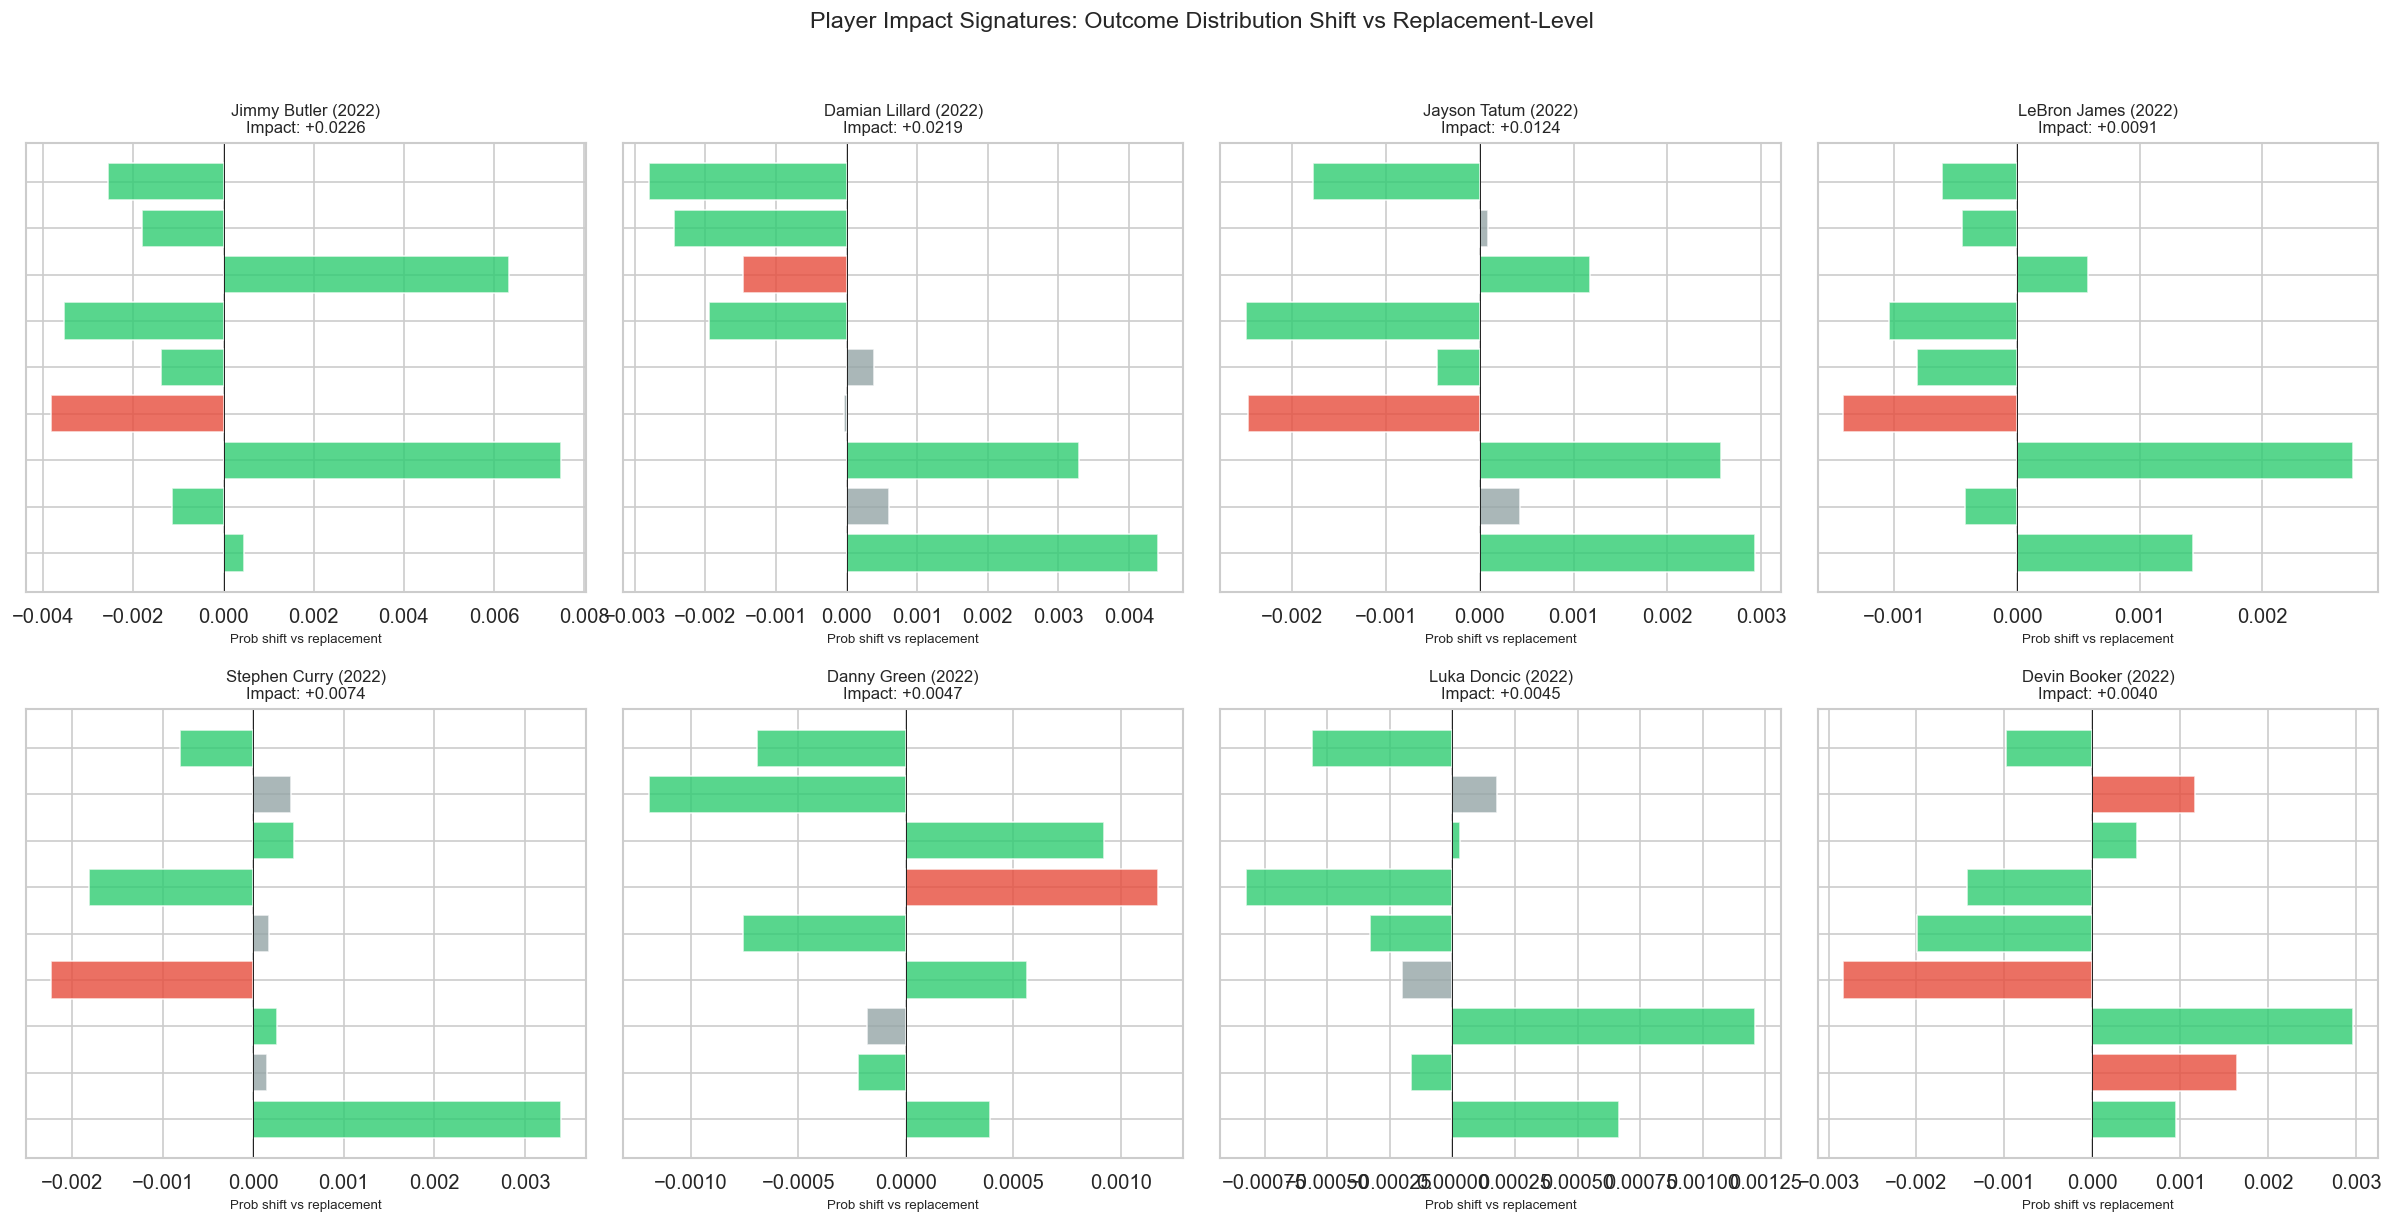

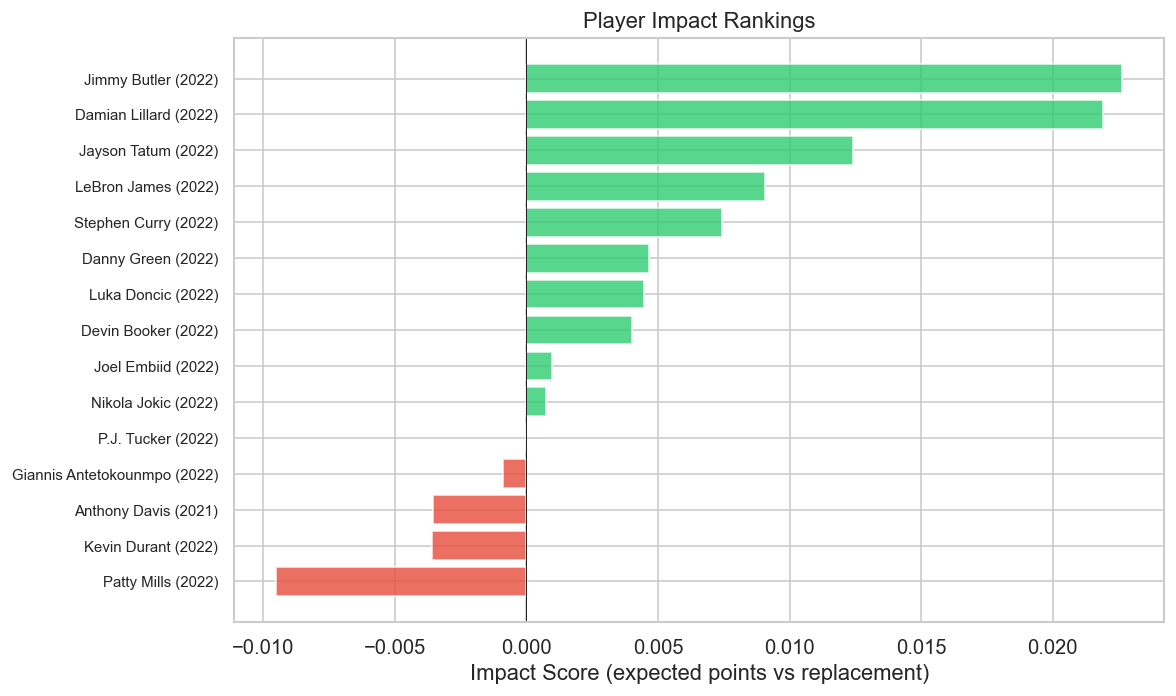

In [5]:
# Visualize impact signatures — per-outcome distribution shift for top players
n_show = min(8, len(impact_results))
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=True)
axes = axes.ravel()

for i, r in enumerate(impact_results[:n_show]):
    ax = axes[i]
    colors = ['green' if d > 0 else 'red' for d in r['delta']]
    # Green for outcomes where being positive is good (made shots) or reducing bad outcomes
    # Actually, let's color by whether the shift is "good for offense"
    good_shift = [True, False, True, True, False, False, True, False, False]
    colors = []
    for j, d in enumerate(r['delta']):
        if (good_shift[j] and d > 0) or (not good_shift[j] and d < 0):
            colors.append('#2ecc71')  # good
        elif abs(d) < 0.001:
            colors.append('#95a5a6')  # neutral
        else:
            colors.append('#e74c3c')  # bad

    bars = ax.barh(range(NUM_OUTCOMES), r['delta'], color=colors, alpha=0.8)
    ax.set_yticks(range(NUM_OUTCOMES))
    if i % 4 == 0:
        ax.set_yticklabels([n.replace('_', '\n') for n in outcome_names], fontsize=8)
    else:
        ax.set_yticklabels([])
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_title(f"{r['name']} ({r['season']})\nImpact: {r['impact_score']:+.4f}", fontsize=10)
    ax.set_xlabel("Prob shift vs replacement", fontsize=8)

plt.suptitle("Player Impact Signatures: Outcome Distribution Shift vs Replacement-Level",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Impact score ranking bar chart
fig, ax = plt.subplots(figsize=(10, 6))
names = [f"{r['name']} ({r['season']})" for r in impact_results]
scores = [r['impact_score'] for r in impact_results]
colors = ['#2ecc71' if s > 0 else '#e74c3c' for s in scores]
ax.barh(range(len(names)), scores, color=colors, alpha=0.8)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel("Impact Score (expected points vs replacement)")
ax.set_title("Player Impact Rankings")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Replacement Value Baseline Comparison

The choice of "replacement-level" baseline affects all impact scores. We compare three definitions:
1. **Global centroid**: Base embedding closest to the centroid of all base embeddings (used above)
2. **Low-minute centroid**: Centroid of players with below-median minutes — captures "end of bench" quality
3. **Archetype-specific**: For each player, use the centroid of their archetype cluster — measures impact *relative to role peers*

1. Global centroid replacement: Juwan Morgan (2022)
2. Low-minute centroid replacement: Terence Davis (2023)
3. Archetype-specific replacement (per-player, 8 clusters)

Player                        Global    Low-Min  Archetype
------------------------------------------------------------
LeBron James                 +0.0077    +0.0073    +0.0038
Stephen Curry                +0.0087    +0.0071    +0.0007
Nikola Jokic                 +0.0007    -0.0008    +0.0074
Kevin Durant                 -0.0023    -0.0035    -0.0024
Giannis Antetokounmpo        +0.0009    -0.0002    -0.0013
Luka Doncic                  +0.0048    +0.0029    +0.0029
Jayson Tatum                 +0.0122    +0.0110    +0.0048
Joel Embiid                  +0.0010    -0.0004    +0.0047


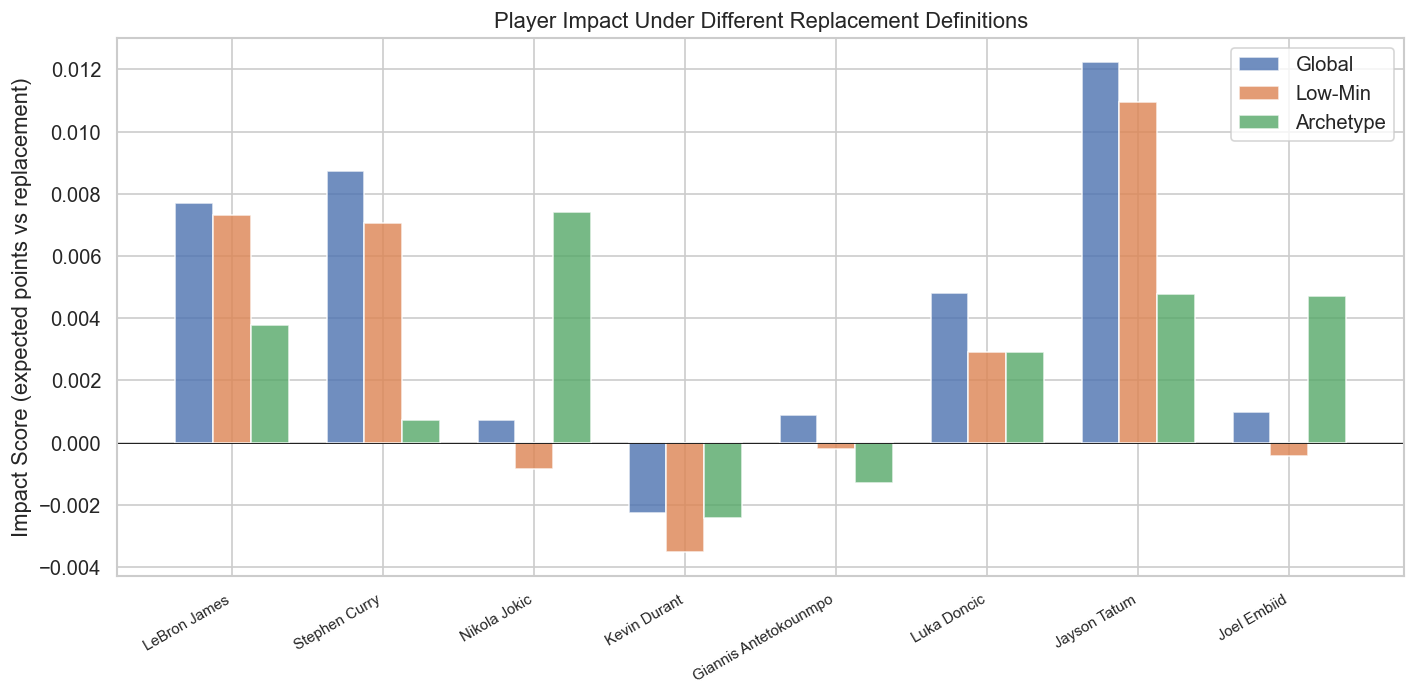

In [6]:
# --- Replacement Value Baseline Comparison ---
# Compare three replacement definitions on a subset of notable players

# Baseline 1: Global centroid (already computed above as replacement_ps_id)
repl_global_ps = replacement_ps_id
print(f"1. Global centroid replacement: {id_to_name.get(repl_global_ps, '?')}")

# Baseline 2: Low-minute centroid
# We don't have minutes data directly, but we can proxy by # of test possessions
# Players with fewer appearances ≈ lower minutes
poss_counts = {ps: len(poss_list) for ps, poss_list in offense_index.items()}
median_count = np.median(list(poss_counts.values()))
low_minute_base_ids = set()
for ps, count in poss_counts.items():
    if count < median_count and ps in ps_to_base_map:
        low_minute_base_ids.add(ps_to_base_map[ps])

low_minute_embs = base_emb[list(low_minute_base_ids)]
low_minute_centroid = low_minute_embs.mean(dim=0)
repl_low_base_id = F.cosine_similarity(base_emb, low_minute_centroid.unsqueeze(0)).argmax().item()

# Find a test-era ps_id for this base player
repl_low_ps = None
for ps, base in ps_to_base_map.items():
    if base == repl_low_base_id and id_to_season.get(ps, 0) >= 2021:
        repl_low_ps = ps
        break
if repl_low_ps is None:
    repl_low_ps = [ps for ps, base in ps_to_base_map.items() if base == repl_low_base_id][0]
print(f"2. Low-minute centroid replacement: {id_to_name.get(repl_low_ps, '?')}")

# Baseline 3: Archetype-specific (per-player)
# Cluster base embeddings to define archetypes (used later in Section 4 too)
base_emb_norm = F.normalize(base_emb, dim=1).numpy()
km = KMeans(n_clusters=8, random_state=42, n_init=10)
archetype_labels = km.fit_predict(base_emb_norm)

# Map base_id -> archetype
base_to_archetype = {i: archetype_labels[i] for i in range(num_base)}

# Map player-season IDs to archetypes
ps_to_archetype = {}
for ps, base in ps_to_base_map.items():
    if base < num_base:
        ps_to_archetype[ps] = archetype_labels[base]

archetype_centroids = {}
for c in range(8):
    mask = archetype_labels == c
    archetype_centroids[c] = base_emb[mask].mean(dim=0)

def get_archetype_replacement(target_ps):
    """Get the replacement player from the same archetype cluster."""
    target_base = ps_to_base_map.get(target_ps)
    if target_base is None:
        return repl_global_ps
    arch = archetype_labels[target_base]
    centroid = archetype_centroids[arch]
    # Find closest base player to this archetype centroid (excluding the target)
    sims = F.cosine_similarity(base_emb, centroid.unsqueeze(0))
    sims[target_base] = -1  # exclude self
    repl_base = sims.argmax().item()
    # Find test-era ps_id
    for ps, base in ps_to_base_map.items():
        if base == repl_base and id_to_season.get(ps, 0) >= 2021:
            return ps
    return [ps for ps, base in ps_to_base_map.items() if base == repl_base][0]

print(f"3. Archetype-specific replacement (per-player, 8 clusters)")

# Compare impact scores across baselines for top players
print(f"\n{'Player':<25s} {'Global':>10s} {'Low-Min':>10s} {'Archetype':>10s}")
print("-" * 60)

comparison_results = []
for dname, bbref, season, target_ps, count in notable_found[:8]:
    poss_indices = [idx for idx, slot in offense_index[target_ps]]
    slots = [slot for idx, slot in offense_index[target_ps]]
    if len(poss_indices) > 500:
        sample = np.random.choice(len(poss_indices), 500, replace=False)
        poss_indices = [poss_indices[i] for i in sample]
        slots = [slots[i] for i in sample]

    players_real = test_ds.players[poss_indices].copy()
    states = test_ds.state[poss_indices].copy()

    impacts = {}
    for label, repl_ps in [("Global", repl_global_ps),
                            ("Low-Min", repl_low_ps),
                            ("Archetype", get_archetype_replacement(target_ps))]:
        players_repl = players_real.copy()
        for i, slot in enumerate(slots):
            players_repl[i, slot] = repl_ps

        probs_real_list, probs_repl_list = [], []
        for start in range(0, len(players_real), 512):
            end = min(start + 512, len(players_real))
            pr, _ = predict_batch(players_real[start:end], states[start:end])
            pp, _ = predict_batch(players_repl[start:end], states[start:end])
            probs_real_list.append(pr)
            probs_repl_list.append(pp)

        pr = torch.cat(probs_real_list)
        pp = torch.cat(probs_repl_list)
        impacts[label] = (favorability(pr) - favorability(pp)).mean().item()

    comparison_results.append((dname, impacts))
    print(f"{dname:<25s} {impacts['Global']:>+10.4f} {impacts['Low-Min']:>+10.4f} {impacts['Archetype']:>+10.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_results))
width = 0.25
for i, label in enumerate(["Global", "Low-Min", "Archetype"]):
    vals = [r[1][label] for r in comparison_results]
    ax.bar(x + i * width, vals, width, label=label, alpha=0.8)

ax.set_xticks(x + width)
ax.set_xticklabels([r[0] for r in comparison_results], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Impact Score (expected points vs replacement)")
ax.set_title("Player Impact Under Different Replacement Definitions")
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## Section 3: Lineup Optimization & Counterfactuals

Given a 4-player offensive unit, score every eligible player for the 5th slot. Then explore "what if" scenarios by swapping players between lineups.

In [7]:
@torch.no_grad()
def find_best_5th(four_off_ids, five_def_ids, candidate_ps_ids, state=None,
                  batch_size=256):
    """Score every candidate for the 5th offensive slot.

    Args:
        four_off_ids: list of 4 player-season IDs (offense)
        five_def_ids: list of 5 player-season IDs (defense)
        candidate_ps_ids: list of candidate player-season IDs to try
        state: [3] game state (default: neutral)

    Returns:
        List of (ps_id, favorability_score, probs) sorted by favorability desc
    """
    if state is None:
        state = NEUTRAL_STATE

    results = []
    # Build all lineups: [candidate] + four_off + five_def
    all_lineups = []
    for cand in candidate_ps_ids:
        lineup = list(four_off_ids) + [cand] + list(five_def_ids)
        all_lineups.append(lineup)

    all_lineups = np.array(all_lineups)  # [N, 10]
    states = np.tile(state, (len(all_lineups), 1)).astype(np.float32)  # [N, 3]

    all_probs = []
    for start in range(0, len(all_lineups), batch_size):
        end = min(start + batch_size, len(all_lineups))
        probs, _ = predict_batch(all_lineups[start:end], states[start:end])
        all_probs.append(probs)

    all_probs = torch.cat(all_probs, dim=0)  # [N, 9]
    favs = favorability(all_probs)  # [N]

    results = [(cand, favs[i].item(), all_probs[i].numpy())
               for i, cand in enumerate(candidate_ps_ids)]
    results.sort(key=lambda x: x[1], reverse=True)
    return results

# Get all test-era player-season IDs as candidates
test_era_ps = [int(row["player_season_id"]) for _, row in lu.iterrows()
               if int(row["season"]) >= 2021]
print(f"Test-era candidates: {len(test_era_ps)}")

# --- Scenario 1: 2023 Warriors without a center ---
# Curry, Thompson, Wiggins, Green + ?
warriors_4 = [ps_id("curryst01", 2023), ps_id("thompkl01", 2023),
              ps_id("wiggian01", 2023), ps_id("greendr01", 2023)]
# Generic defense (pick a strong test-era team)
generic_def = [ps_id("tatumja01", 2023), ps_id("brownja02", 2023),
               ps_id("smartma01", 2023), ps_id("whitede01", 2023),
               ps_id("horfoal01", 2023)]

# Check all IDs exist
scenarios = []
w4_valid = all(x is not None for x in warriors_4)
def_valid = all(x is not None for x in generic_def)

if w4_valid and def_valid:
    w4_names = [id_to_name.get(p, "?") for p in warriors_4]
    print(f"\nScenario 1: Warriors 4 = {w4_names}")
    scenarios.append(("2023 Warriors + ?", warriors_4, generic_def))
else:
    print(f"Warriors IDs missing: off={warriors_4}, def={generic_def}")

# --- Scenario 2: 2023 Nuggets without PG ---
nuggets_4 = [ps_id("jokicni01", 2023), ps_id("gordoaa01", 2023),
             ps_id("portemi02", 2023), ps_id("caldwke01", 2023)]

if all(x is not None for x in (nuggets_4 or [])):
    n4_names = [id_to_name.get(p, "?") for p in nuggets_4]
    print(f"Scenario 2: Nuggets 4 = {n4_names}")
    scenarios.append(("2023 Nuggets + ?", nuggets_4, generic_def))

# --- Scenario 3: 2023 Celtics without a big ---
celtics_4 = [ps_id("tatumja01", 2023), ps_id("brownja02", 2023),
             ps_id("smartma01", 2023), ps_id("whitede01", 2023)]
# Different defense for variety
alt_def = [ps_id("curryst01", 2023), ps_id("thompkl01", 2023),
           ps_id("wiggian01", 2023), ps_id("greendr01", 2023),
           ps_id("loloney01", 2023)]
# Fallback to generic def if alt fails
if all(x is not None for x in (celtics_4 or [])):
    c4_names = [id_to_name.get(p, "?") for p in celtics_4]
    print(f"Scenario 3: Celtics 4 = {c4_names}")
    use_def = generic_def  # use same defense for comparability
    scenarios.append(("2023 Celtics + ?", celtics_4, use_def))

print(f"\n{len(scenarios)} scenarios ready")

Test-era candidates: 1803

Scenario 1: Warriors 4 = ['Stephen Curry (2023)', 'Klay Thompson (2023)', 'Andrew Wiggins (2023)', 'Draymond Green (2023)']
Scenario 3: Celtics 4 = ['Jayson Tatum (2023)', 'Jaylen Brown (2023)', 'Marcus Smart (2023)', 'Derrick White (2023)']

2 scenarios ready



  2023 Warriors + ?
  Offense: ['Stephen Curry (2023)', 'Klay Thompson (2023)', 'Andrew Wiggins (2023)', 'Draymond Green (2023)']
  Defense: ['Jayson Tatum (2023)', 'Jaylen Brown (2023)', 'Marcus Smart (2023)', 'Derrick White (2023)', 'Al Horford (2023)']

  TOP 15 — Best 5th player:
     1. Evan Fournier (2023)                fav=+1.1069
     2. Evan Fournier (2022)                fav=+1.1069
     3. Evan Fournier (2021)                fav=+1.1069
     4. Kentavious Caldwell-Pope (2022)     fav=+1.1054
     5. Kentavious Caldwell-Pope (2021)     fav=+1.1054
     6. Kentavious Caldwell-Pope (2023)     fav=+1.1054
     7. Mike James (2022)                   fav=+1.1039
     8. Luke Kennard (2023)                 fav=+1.1038
     9. Luke Kennard (2022)                 fav=+1.1038
    10. Luke Kennard (2021)                 fav=+1.1038
    11. Rodney McGruder (2021)              fav=+1.1037
    12. Rodney McGruder (2023)              fav=+1.1037
    13. Rodney McGruder (2022)            

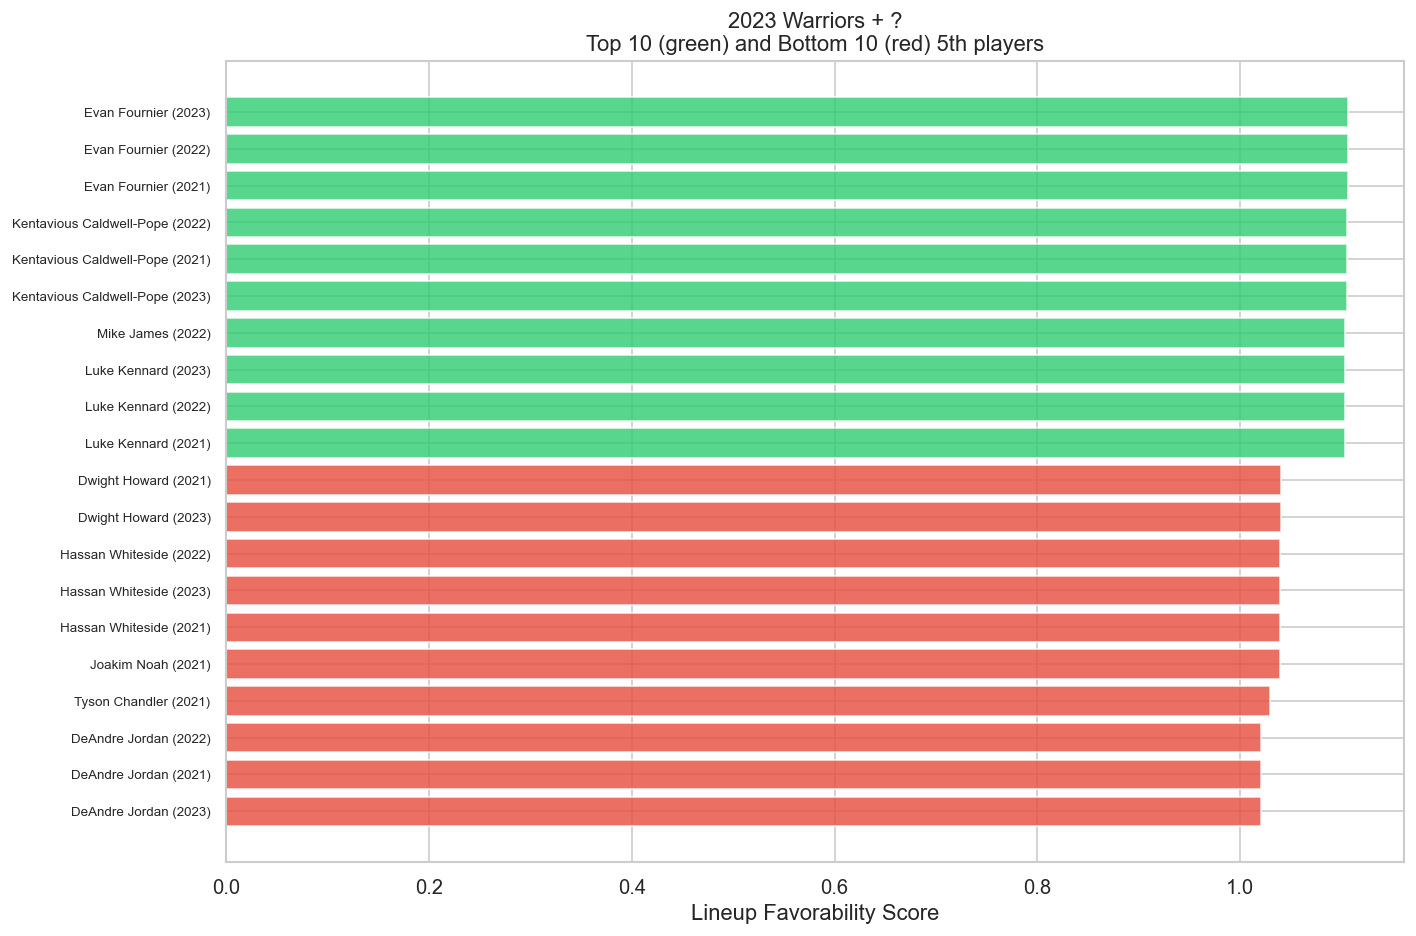


  2023 Celtics + ?
  Offense: ['Jayson Tatum (2023)', 'Jaylen Brown (2023)', 'Marcus Smart (2023)', 'Derrick White (2023)']
  Defense: ['Jayson Tatum (2023)', 'Jaylen Brown (2023)', 'Marcus Smart (2023)', 'Derrick White (2023)', 'Al Horford (2023)']

  TOP 15 — Best 5th player:
     1. Jonas Valanciunas (2022)            fav=+1.1178
     2. Jonas Valanciunas (2021)            fav=+1.1178
     3. Jonas Valanciunas (2023)            fav=+1.1178
     4. Rudy Gay (2022)                     fav=+1.1172
     5. Rudy Gay (2021)                     fav=+1.1172
     6. Rudy Gay (2023)                     fav=+1.1172
     7. Luc Mbah a Moute (2021)             fav=+1.1159
     8. Tobias Harris (2023)                fav=+1.1152
     9. Tobias Harris (2022)                fav=+1.1152
    10. Tobias Harris (2021)                fav=+1.1152
    11. Aaron Gordon (2023)                 fav=+1.1151
    12. Aaron Gordon (2022)                 fav=+1.1151
    13. Aaron Gordon (2021)                 fav=

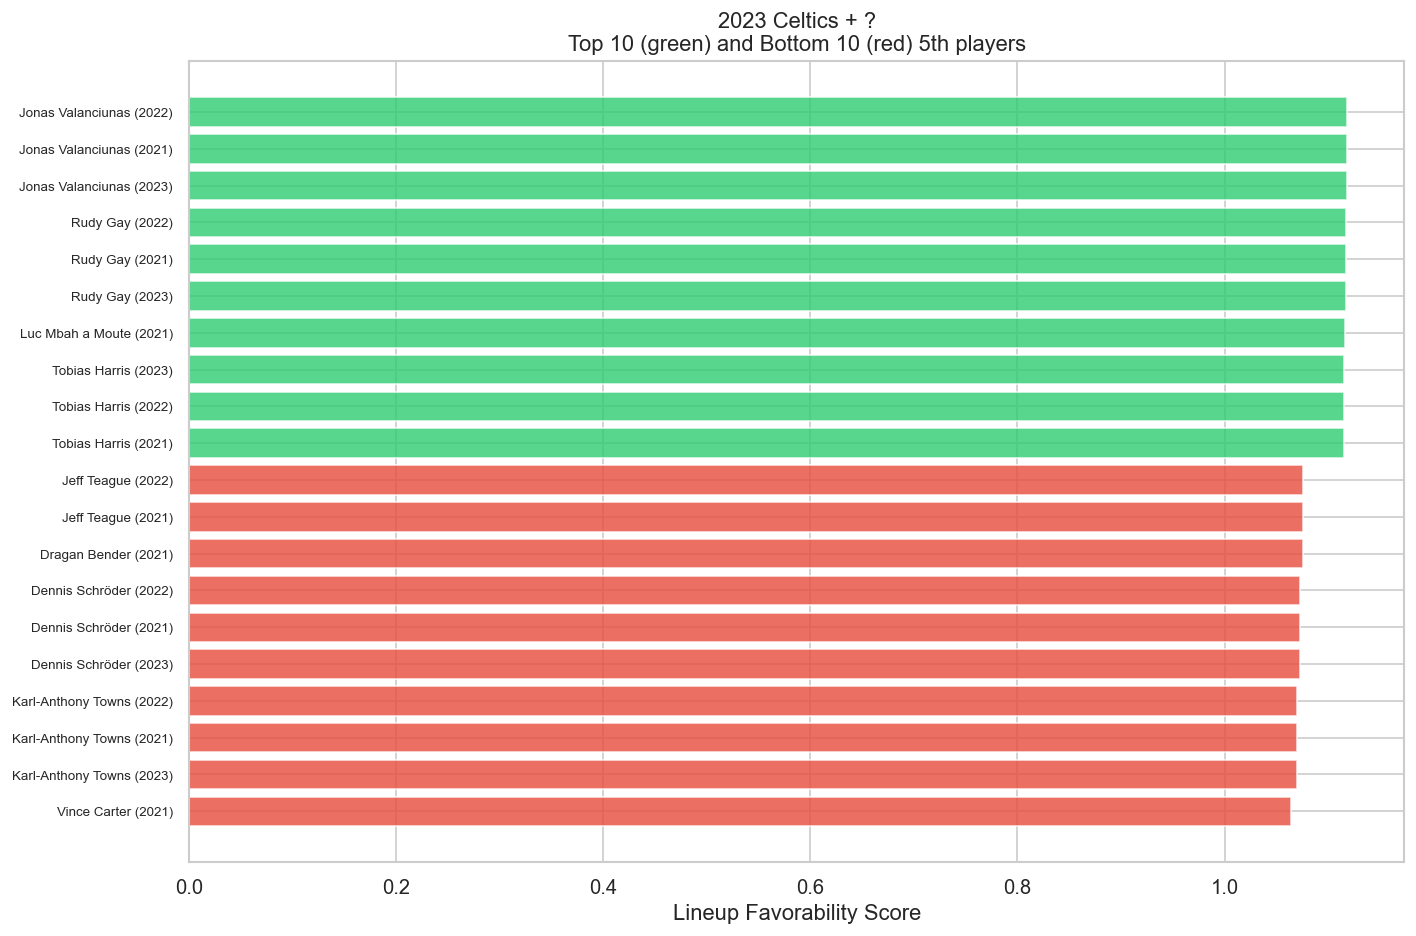

In [8]:
# Run lineup optimization for each scenario
for scenario_name, four_off, five_def in scenarios:
    print(f"\n{'='*70}")
    print(f"  {scenario_name}")
    print(f"  Offense: {[id_to_name.get(p, '?') for p in four_off]}")
    print(f"  Defense: {[id_to_name.get(p, '?') for p in five_def]}")
    print(f"{'='*70}")

    # Exclude players already in the lineup
    exclude = set(four_off + five_def)
    candidates = [p for p in test_era_ps if p not in exclude]

    results = find_best_5th(four_off, five_def, candidates)

    print(f"\n  TOP 15 — Best 5th player:")
    for rank, (cand, fav, probs) in enumerate(results[:15], 1):
        print(f"    {rank:2d}. {id_to_name.get(cand, cand):35s} fav={fav:+.4f}")

    print(f"\n  BOTTOM 5 — Worst 5th player:")
    for rank, (cand, fav, probs) in enumerate(results[-5:], len(results)-4):
        print(f"    {rank:2d}. {id_to_name.get(cand, cand):35s} fav={fav:+.4f}")

    # Visualization: top and bottom 10
    show_top = results[:10]
    show_bot = results[-10:]
    all_show = show_top + show_bot

    fig, ax = plt.subplots(figsize=(12, 8))
    names = [id_to_name.get(r[0], str(r[0])) for r in all_show]
    favs = [r[1] for r in all_show]
    colors = ['#2ecc71'] * 10 + ['#e74c3c'] * 10
    ax.barh(range(len(names)), favs, color=colors, alpha=0.8)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=8)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel("Lineup Favorability Score")
    ax.set_title(f"{scenario_name}\nTop 10 (green) and Bottom 10 (red) 5th players")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

### Defensive Matchup Optimization

The flip side of offensive optimization: fix an elite offensive unit and find which defenders minimize their expected points. The model takes 5 offensive + 5 defensive players — we should exploit both sides.

Defensive shell: ['Marcus Smart (2023)', 'Miles Bridges (2023)', 'Jrue Holiday (2023)', 'Bam Adebayo (2023)']

  vs 2023 Warriors
  Offense: ['Stephen Curry (2023)', 'Klay Thompson (2023)', 'Andrew Wiggins (2023)', 'Draymond Green (2023)', 'Jalen Green (2023)']
  Defense shell: ['Marcus Smart (2023)', 'Miles Bridges (2023)', 'Jrue Holiday (2023)', 'Bam Adebayo (2023)'] + ?

  TOP 15 — Best 5th defender (lowest offensive favorability):
     1. Andrew Wiggins (2022)               opp_fav=+0.9516
     2. Andrew Wiggins (2021)               opp_fav=+0.9516
     3. Karl-Anthony Towns (2022)           opp_fav=+0.9576
     4. Karl-Anthony Towns (2021)           opp_fav=+0.9576
     5. Karl-Anthony Towns (2023)           opp_fav=+0.9576
     6. Larry Nance (2021)                  opp_fav=+0.9644
     7. Larry Nance (2022)                  opp_fav=+0.9644
     8. Larry Nance (2023)                  opp_fav=+0.9644
     9. Julius Randle (2022)                opp_fav=+0.9663
    10. Julius Randle

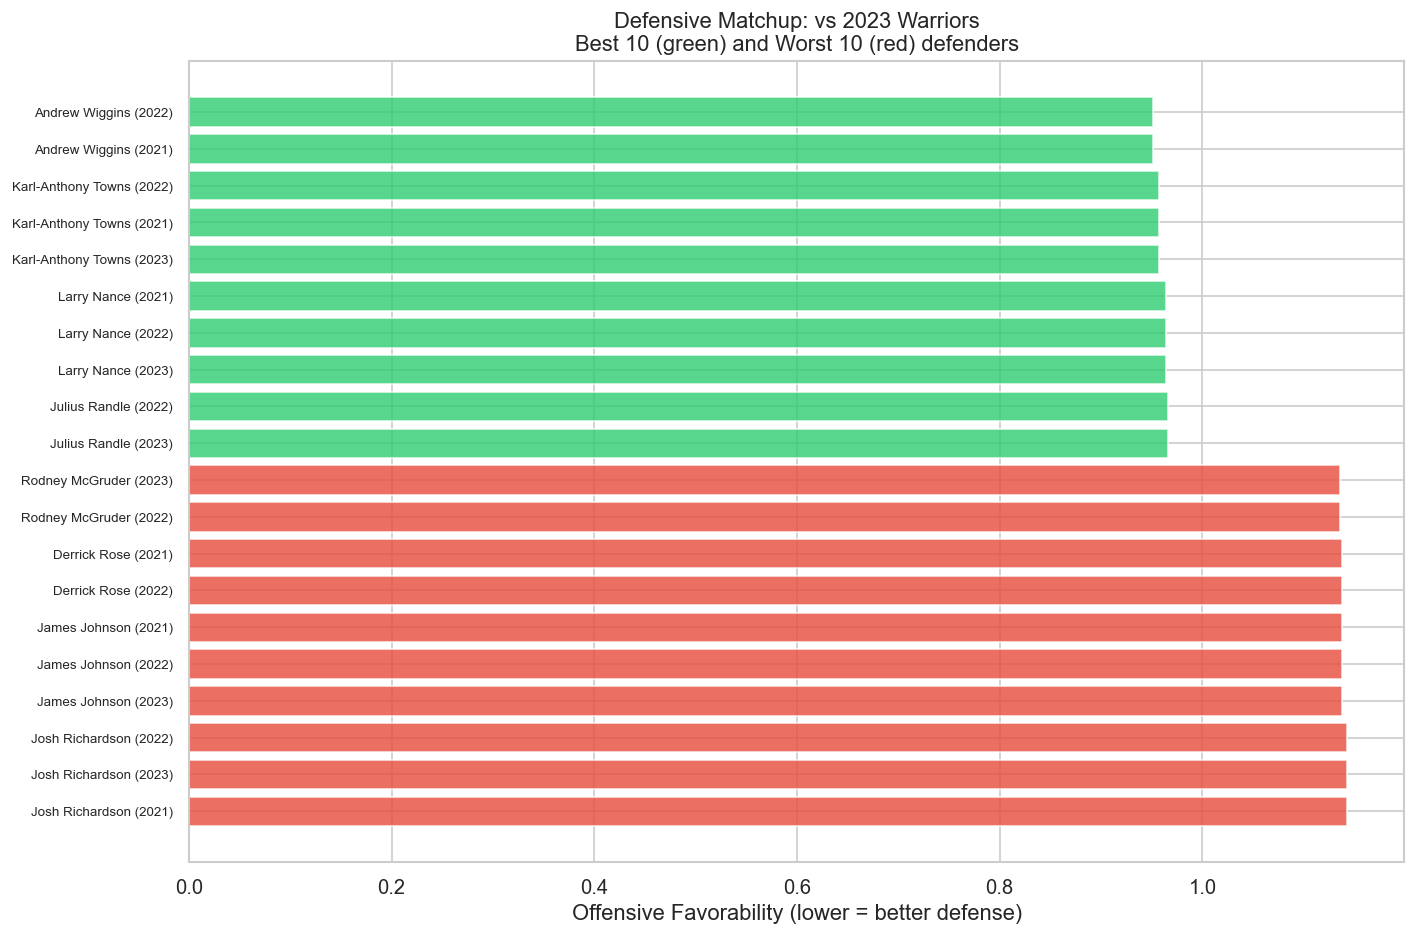

In [9]:
# --- Defensive Matchup Optimization ---
# Fix a strong offensive lineup, then find the best defenders for each slot

@torch.no_grad()
def find_best_defender(five_off_ids, four_def_ids, candidate_ps_ids, def_slot=4,
                       state=None, batch_size=256):
    """Score every candidate for an open defensive slot.
    LOWER favorability = better defense (offense scores less).

    Args:
        five_off_ids: list of 5 offensive player-season IDs
        four_def_ids: list of 4 defensive player-season IDs
        candidate_ps_ids: candidates for the open slot
        def_slot: which defensive slot is open (0-4, maps to lineup positions 5-9)
        state: game state
    Returns:
        List of (ps_id, favorability_score) sorted by favorability ASC (best defense first)
    """
    if state is None:
        state = NEUTRAL_STATE

    all_lineups = []
    for cand in candidate_ps_ids:
        defense = list(four_def_ids)
        defense.insert(def_slot, cand)
        lineup = list(five_off_ids) + defense
        all_lineups.append(lineup)

    all_lineups = np.array(all_lineups)
    states = np.tile(state, (len(all_lineups), 1)).astype(np.float32)

    all_probs = []
    for start in range(0, len(all_lineups), batch_size):
        end = min(start + batch_size, len(all_lineups))
        probs, _ = predict_batch(all_lineups[start:end], states[start:end])
        all_probs.append(probs)

    all_probs = torch.cat(all_probs, dim=0)
    favs = favorability(all_probs)

    results = [(cand, favs[i].item()) for i, cand in enumerate(candidate_ps_ids)]
    results.sort(key=lambda x: x[1])  # ascending = best defense first
    return results

# Define elite offensive units to defend against
def_scenarios = []

# Warriors offense (if available)
warriors_5 = None
if w4_valid:
    # Add Looney or another center
    center_candidates = [ps_id("loloney01", 2023), ps_id("greenja05", 2023)]
    for c in center_candidates:
        if c is not None:
            warriors_5 = warriors_4 + [c]
            break
    if warriors_5 is None:
        warriors_5 = warriors_4 + [test_era_ps[0]]  # fallback
    def_scenarios.append(("vs 2023 Warriors", warriors_5))

# Build generic 4-man defense shell (leave one slot open)
# Use solid defenders from test era
generic_def_4 = []
for bbref in ["smartma01", "bridgmi02", "holidjr01", "adebaba01"]:
    for season in [2023, 2022, 2021]:
        pid = ps_id(bbref, season)
        if pid is not None:
            generic_def_4.append(pid)
            break
    if len(generic_def_4) == len([b for b in ["smartma01", "bridgmi02", "holidjr01", "adebaba01"]
                                   if ps_id(b, 2023) is not None or ps_id(b, 2022) is not None]):
        break

# Pad to 4 if needed
while len(generic_def_4) < 4:
    generic_def_4.append(test_era_ps[len(generic_def_4)])

print(f"Defensive shell: {[id_to_name.get(p, '?') for p in generic_def_4]}")

for scenario_name, five_off in def_scenarios:
    exclude = set(five_off + generic_def_4)
    candidates = [p for p in test_era_ps if p not in exclude]

    print(f"\n{'='*70}")
    print(f"  {scenario_name}")
    print(f"  Offense: {[id_to_name.get(p, '?') for p in five_off]}")
    print(f"  Defense shell: {[id_to_name.get(p, '?') for p in generic_def_4]} + ?")
    print(f"{'='*70}")

    results = find_best_defender(five_off, generic_def_4, candidates)

    print(f"\n  TOP 15 — Best 5th defender (lowest offensive favorability):")
    for rank, (cand, fav) in enumerate(results[:15], 1):
        print(f"    {rank:2d}. {id_to_name.get(cand, cand):35s} opp_fav={fav:+.4f}")

    print(f"\n  BOTTOM 5 — Worst 5th defender:")
    for rank, (cand, fav) in enumerate(results[-5:], len(results)-4):
        print(f"    {rank:2d}. {id_to_name.get(cand, cand):35s} opp_fav={fav:+.4f}")

    # Visualization
    show_top = results[:10]
    show_bot = results[-10:]
    all_show = show_top + show_bot

    fig, ax = plt.subplots(figsize=(12, 8))
    names = [id_to_name.get(r[0], str(r[0])) for r in all_show]
    favs_plot = [r[1] for r in all_show]
    colors = ['#2ecc71'] * 10 + ['#e74c3c'] * 10
    ax.barh(range(len(names)), favs_plot, color=colors, alpha=0.8)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_xlabel("Offensive Favorability (lower = better defense)")
    ax.set_title(f"Defensive Matchup: {scenario_name}\nBest 10 (green) and Worst 10 (red) defenders")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## Section 4: Superstar Ecosystem Modeling

For each superstar, find which player archetypes in the other 4 offensive slots maximize lineup favorability. We cluster all base players into archetypes (K-means, K=8), then for each superstar, measure which archetypes they benefit from most.

In [10]:
# Archetypes already clustered in Section 2 (replacement baseline cell)
# Reuse: archetype_labels, base_to_archetype, ps_to_archetype, km

# Get test-era players per archetype
archetype_ps = defaultdict(list)
for ps in test_era_ps:
    arch = ps_to_archetype.get(ps)
    if arch is not None:
        archetype_ps[arch].append(ps)

# Describe archetypes by their most common members
print("Archetypes discovered:")
for c in range(8):
    members = [base_to_player.get(i, "?") for i in range(num_base) if archetype_labels[i] == c]
    member_names = [display_name(m) for m in members[:8]]
    print(f"  Cluster {c} ({len(members)} players): {', '.join(member_names)}...")

Archetypes discovered:
  Cluster 0 (130 players): Álex Abrines, LaMarcus Aldridge, Al-Farouq Aminu, James Anderson, Justin Anderson, Kyle Anderson, Ryan Anderson, Trevor Ariza...
  Cluster 1 (605 players): Precious Achiuwa, Hassan Adams, Jaylen Adams, Deng Adel, DeVaughn Akoon-Purcell, Santi Aldama, Nickeil Alexander-Walker, Ty-Shon Alexander...
  Cluster 2 (255 players): Joe Alexander, Kyle Alexander, Lance Allred, Peter Aluma, Chris Anstey, Kostas Antetokounmpo, James Augustine, Anthony Avent...
  Cluster 3 (283 players): Alex Acker, Maurice Ager, Blake Ahearn, Josh Akognon, Rafer Alston, Antonio Anderson, Ryan Arcidiacono, Gilbert Arenas...
  Cluster 4 (254 players): Quincy Acy, Steven Adams, Bam Adebayo, Jeff Adrien, Alexis Ajinça, Solomon Alabi, Furkan Aldemir, Cole Aldrich...
  Cluster 5 (256 players): Mahmoud Abdul-Rauf, Tariq Abdul-Wahad, Cory Alexander, Courtney Alexander, Ray Allen, Derek Anderson, Kenny Anderson, Nick Anderson...
  Cluster 6 (262 players): Jordan Adams, Arro

Ecosystem modeling:   0%|          | 0/6 [00:00<?, ?it/s]

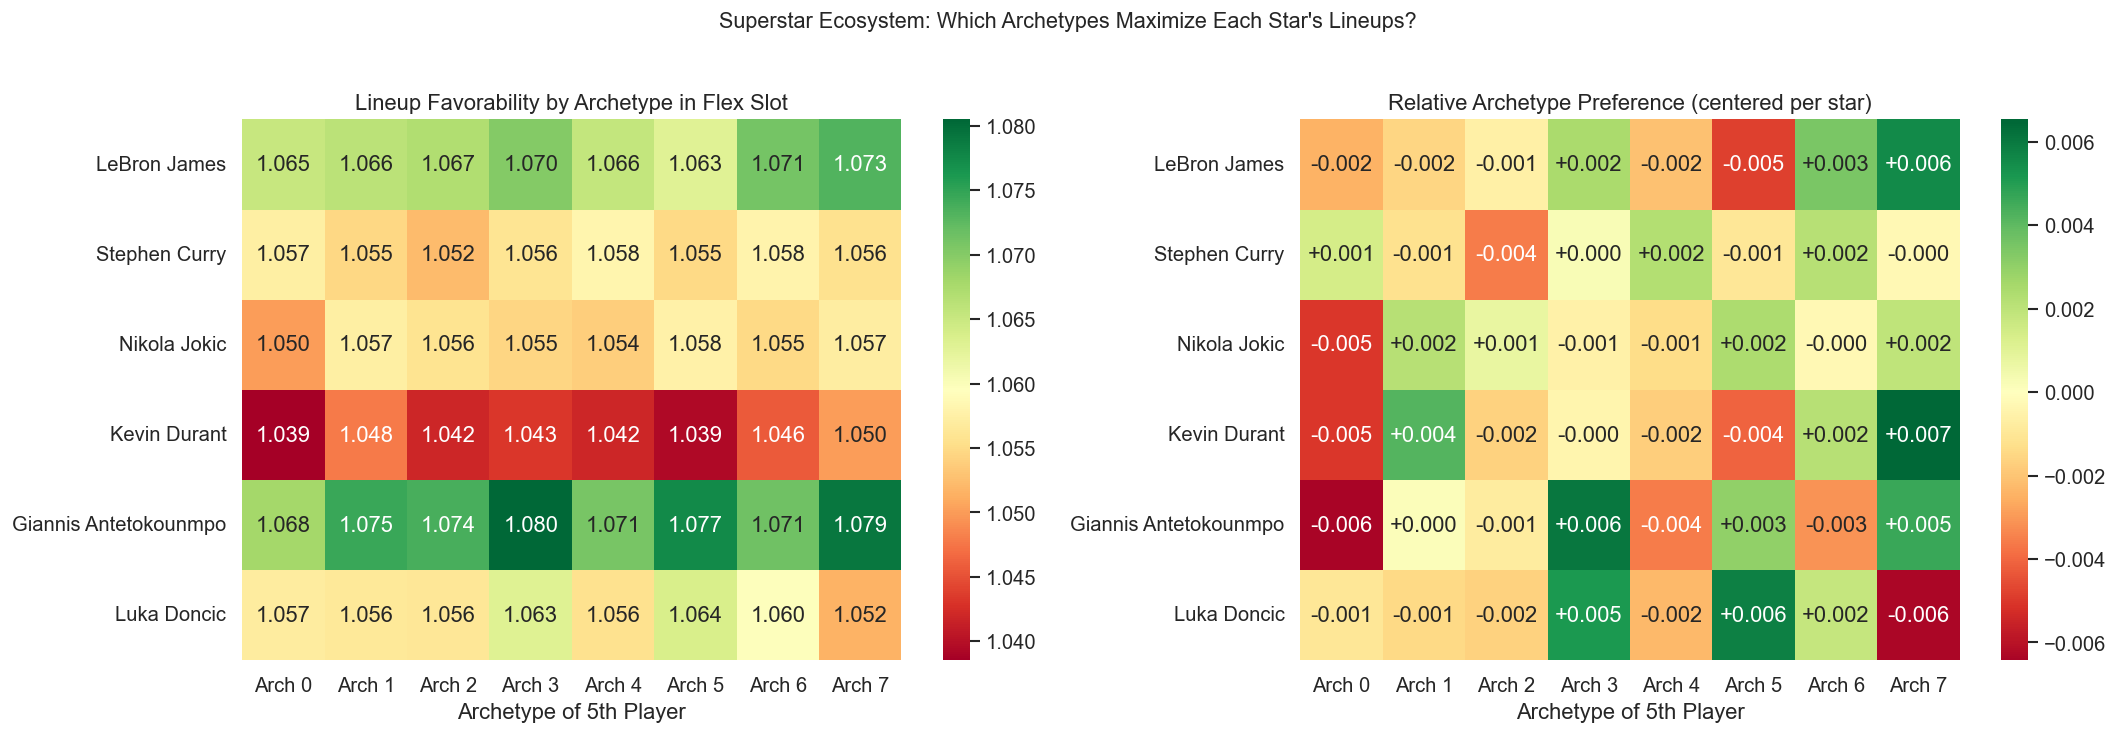

LeBron James: best with Archetype 7 (+0.0055), worst with Archetype 5 (-0.0048)
Stephen Curry: best with Archetype 4 (+0.0023), worst with Archetype 2 (-0.0036)
Nikola Jokic: best with Archetype 5 (+0.0024), worst with Archetype 0 (-0.0051)
Kevin Durant: best with Archetype 7 (+0.0065), worst with Archetype 0 (-0.0050)
Giannis Antetokounmpo: best with Archetype 3 (+0.0061), worst with Archetype 0 (-0.0064)
Luka Doncic: best with Archetype 5 (+0.0058), worst with Archetype 7 (-0.0063)


In [11]:
# For each superstar, measure which archetype in each slot maximizes favorability
# Simplified: fix star in slot 0, sample 3 random teammates from other archetypes,
# then vary the archetype in slot 4 (the "flex" slot)

superstars = []
for dname, bbref, season, target_ps, count in notable_found[:6]:  # top 6 by impact
    superstars.append((dname, target_ps))

N_SAMPLES = 50  # lineups sampled per (superstar, archetype) pair

ecosystem_results = {}  # star_name -> {archetype -> mean_favorability}

for star_name, star_ps in tqdm(superstars, desc="Ecosystem modeling"):
    star_arch = ps_to_archetype.get(star_ps)
    arch_favs = {}

    for target_arch in range(8):
        # Sample lineups: star + 3 random teammates + 1 from target_arch
        # Pick 3 random test-era players for the middle slots
        other_archs = [a for a in range(8) if a != star_arch and a != target_arch]
        favs = []

        for _ in range(N_SAMPLES):
            # Random 3 teammates from random archetypes
            teammates = []
            for a in np.random.choice(other_archs, 3, replace=True):
                pool = archetype_ps[a]
                if pool:
                    teammates.append(np.random.choice(pool))
            if len(teammates) < 3:
                continue

            # 1 player from target archetype
            target_pool = archetype_ps[target_arch]
            if not target_pool:
                continue
            target_player = np.random.choice(target_pool)

            # Random defense
            def_players = np.random.choice(test_era_ps, 5, replace=False).tolist()

            lineup = [star_ps] + teammates + [target_player] + def_players
            probs, _ = predict_lineup(lineup, NEUTRAL_STATE)
            favs.append(favorability(probs).item())

        if favs:
            arch_favs[target_arch] = np.mean(favs)

    ecosystem_results[star_name] = arch_favs

# Heatmap: superstar x archetype
star_names = list(ecosystem_results.keys())
matrix = np.zeros((len(star_names), 8))
for i, sn in enumerate(star_names):
    for arch, fav in ecosystem_results[sn].items():
        matrix[i, arch] = fav

# Normalize per star (show relative preference)
matrix_norm = matrix - matrix.mean(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Raw favorability
sns.heatmap(matrix, annot=True, fmt=".3f", cmap="RdYlGn", ax=axes[0],
            xticklabels=[f"Arch {i}" for i in range(8)],
            yticklabels=star_names)
axes[0].set_title("Lineup Favorability by Archetype in Flex Slot")
axes[0].set_xlabel("Archetype of 5th Player")

# Relative (per-star centered)
sns.heatmap(matrix_norm, annot=True, fmt="+.3f", cmap="RdYlGn", center=0, ax=axes[1],
            xticklabels=[f"Arch {i}" for i in range(8)],
            yticklabels=star_names)
axes[1].set_title("Relative Archetype Preference (centered per star)")
axes[1].set_xlabel("Archetype of 5th Player")

plt.suptitle("Superstar Ecosystem: Which Archetypes Maximize Each Star's Lineups?",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Print interpretation
for i, sn in enumerate(star_names):
    best_arch = np.argmax(matrix_norm[i])
    worst_arch = np.argmin(matrix_norm[i])
    print(f"{sn}: best with Archetype {best_arch} ({matrix_norm[i, best_arch]:+.4f}), "
          f"worst with Archetype {worst_arch} ({matrix_norm[i, worst_arch]:+.4f})")

## Section 5: Lineup Chemistry / System Effects

The delta between what static embeddings predict and what the contextual model predicts captures emergent interaction properties — chemistry, spacing, scheme fit. This is what the transformer's self-attention learns about player-player interactions.

**Method:** For each lineup, compare pre-encoder representations (static, no interactions) with post-encoder representations (contextual, after self-attention). The magnitude of this change is the "chemistry score."

**Important caveat:** A large representational shift might indicate "great chemistry" OR simply an unusual/unorthodox lineup that forces the model to aggressively adjust tokens. High chemistry score ≠ good chemistry. To validate, we would need to correlate chemistry scores against actual lineup over/underperformance (e.g., actual Net Rating minus predicted Net Rating from individual player stats). This section explores the distribution and identifies high/low chemistry lineups, but the chemistry interpretation requires external validation against real performance data.

Chemistry scores:   0%|          | 0/98 [00:00<?, ?it/s]

Chemistry scores: mean=0.6873, std=0.0642, min=0.4842, max=0.8633


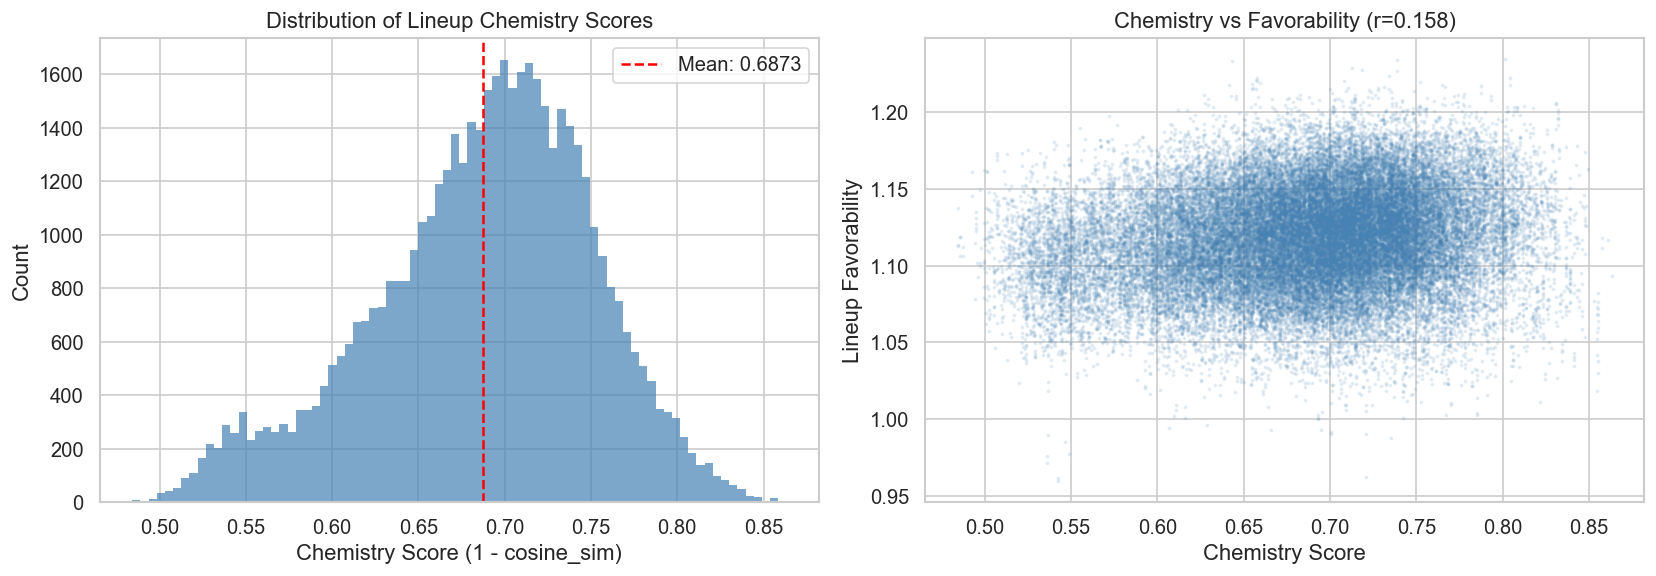

In [12]:
@torch.no_grad()
def compute_chemistry_batch(players_batch, state_batch):
    """Compute chemistry score for a batch of lineups.

    Chemistry = 1 - cosine_sim(pre_encoder_off_mean, post_encoder_off_mean)
    Higher = more interaction effects detected by the transformer.

    Returns: chemistry_scores [B], favorability_scores [B]
    """
    pl = torch.as_tensor(players_batch, dtype=torch.long, device=device)
    st = torch.as_tensor(state_batch, dtype=torch.float32, device=device)
    B = pl.shape[0]
    tm = TEAM_IDS.unsqueeze(0).expand(B, -1).to(device)

    # Pre-encoder: composed embeddings + team/position bias
    tok = model._embed_players(pl, tm)        # [B, 10, d_model]
    pre_off = tok[:, :5, :].mean(dim=1)       # [B, d_model] — static offense mean

    # Post-encoder: after self-attention
    h = model.encoder(tok)                     # [B, 10, d_model]
    post_off = h[:, :5, :].mean(dim=1)        # [B, d_model] — contextual offense mean

    # Chemistry = how much the encoder changed the offense representation
    chem = 1.0 - F.cosine_similarity(pre_off, post_off, dim=1)  # [B]

    # Also compute favorability
    off_pooled, _ = model.attn_pool_off(h[:, :5, :])
    def_pooled, _ = model.attn_pool_def(h[:, 5:, :])
    state_repr = model.state_proj(st)
    combined = torch.cat([off_pooled, def_pooled, state_repr], dim=1)
    logits = model.outcome_head(combined)
    fav = favorability(torch.softmax(logits, dim=1).cpu())

    return chem.cpu().numpy(), fav.numpy()

# Compute chemistry for a sample of test possessions
N_CHEM = min(50000, len(test_ds))
chem_indices = np.random.choice(len(test_ds), N_CHEM, replace=False)

all_chem, all_fav = [], []
BS = 512
for start in tqdm(range(0, N_CHEM, BS), desc="Chemistry scores"):
    end = min(start + BS, N_CHEM)
    idx = chem_indices[start:end]
    chem, fav = compute_chemistry_batch(test_ds.players[idx], test_ds.state[idx])
    all_chem.append(chem)
    all_fav.append(fav)

chemistry_scores = np.concatenate(all_chem)
favorability_scores = np.concatenate(all_fav)

print(f"Chemistry scores: mean={chemistry_scores.mean():.4f}, "
      f"std={chemistry_scores.std():.4f}, "
      f"min={chemistry_scores.min():.4f}, max={chemistry_scores.max():.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(chemistry_scores, bins=80, alpha=0.7, color="steelblue", edgecolor="none")
axes[0].axvline(chemistry_scores.mean(), color="red", linestyle="--",
                label=f"Mean: {chemistry_scores.mean():.4f}")
axes[0].set_xlabel("Chemistry Score (1 - cosine_sim)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Lineup Chemistry Scores")
axes[0].legend()

# Scatter: chemistry vs favorability
axes[1].scatter(chemistry_scores, favorability_scores, s=2, alpha=0.1, color="steelblue")
corr = np.corrcoef(chemistry_scores, favorability_scores)[0, 1]
axes[1].set_xlabel("Chemistry Score")
axes[1].set_ylabel("Lineup Favorability")
axes[1].set_title(f"Chemistry vs Favorability (r={corr:.3f})")

plt.tight_layout()
plt.show()

In [13]:
# Top and bottom chemistry lineups
top_chem_idx = np.argsort(-chemistry_scores)[:15]
bot_chem_idx = np.argsort(chemistry_scores)[:15]

def format_lineup(players_10):
    off = [id_to_name.get(int(p), str(p)) for p in players_10[:5]]
    return " | ".join(off)

print("TOP 15 — Highest chemistry (most interaction effects):")
for rank, idx in enumerate(top_chem_idx, 1):
    real_idx = chem_indices[idx]
    lineup_str = format_lineup(test_ds.players[real_idx])
    print(f"  {rank:2d}. chem={chemistry_scores[idx]:.4f} fav={favorability_scores[idx]:+.4f}")
    print(f"      OFF: {lineup_str}")

print("\nBOTTOM 15 — Lowest chemistry (minimal interaction effects):")
for rank, idx in enumerate(bot_chem_idx, 1):
    real_idx = chem_indices[idx]
    lineup_str = format_lineup(test_ds.players[real_idx])
    print(f"  {rank:2d}. chem={chemistry_scores[idx]:.4f} fav={favorability_scores[idx]:+.4f}")
    print(f"      OFF: {lineup_str}")

TOP 15 — Highest chemistry (most interaction effects):
   1. chem=0.8633 fav=+1.0931
      OFF: Alex Caruso (2021) | LeBron James (2021) | Kentavious Caldwell-Pope (2021) | Kyle Kuzma (2021) | Anthony Davis (2021)
   2. chem=0.8613 fav=+1.1168
      OFF: Alex Caruso (2021) | LeBron James (2021) | Kentavious Caldwell-Pope (2021) | Dwight Howard (2021) | Anthony Davis (2021)
   3. chem=0.8573 fav=+1.1114
      OFF: Alex Caruso (2021) | Kentavious Caldwell-Pope (2021) | Dwight Howard (2021) | Rajon Rondo (2021) | Anthony Davis (2021)
   4. chem=0.8573 fav=+1.1181
      OFF: Alex Caruso (2021) | Kentavious Caldwell-Pope (2021) | Dwight Howard (2021) | Rajon Rondo (2021) | Anthony Davis (2021)
   5. chem=0.8556 fav=+1.0592
      OFF: LeBron James (2021) | Kentavious Caldwell-Pope (2021) | Danny Green (2021) | JaVale McGee (2021) | Anthony Davis (2021)
   6. chem=0.8556 fav=+1.0681
      OFF: LeBron James (2021) | Kentavious Caldwell-Pope (2021) | Danny Green (2021) | JaVale McGee (2021) | A

## Section 6: Attention Weight Analysis

Which players does the model focus on? The attention pooling weights reveal which offensive and defensive players the model considers most important for predicting outcomes.

Attention profiles for notable lineups:

  LeBron James (2022) — lineup example
  Offense:
    LeBron James (2022)       0.198 ######### <-- STAR
    Montrezl Harrell (2022)   0.198 #########
    Kyle Kuzma (2022)         0.202 ##########
    Dennis Schröder (2022)    0.200 #########
    Wesley Matthews (2022)    0.203 ##########
  Defense:
    Kelly Oubre (2022)        0.198 #########
    Draymond Green (2022)     0.205 ##########
    James Wiseman (2022)      0.203 ##########
    Stephen Curry (2022)      0.196 #########
    Mychal Mulder (2022)      0.199 #########

  Stephen Curry (2022) — lineup example
  Offense:
    Gary Payton (2022)        0.199 #########
    Andre Iguodala (2022)     0.200 #########
    Nemanja Bjelica (2022)    0.204 ##########
    Stephen Curry (2022)      0.204 ########## <-- STAR
    Otto Porter (2022)        0.193 #########
  Defense:
    Garrett Temple (2022)     0.193 #########
    Kira Lewis Jr. (2022)     0.203 ##########
    Trey Murphy III (2022)  

Aggregate attention:   0%|          | 0/20 [00:00<?, ?it/s]

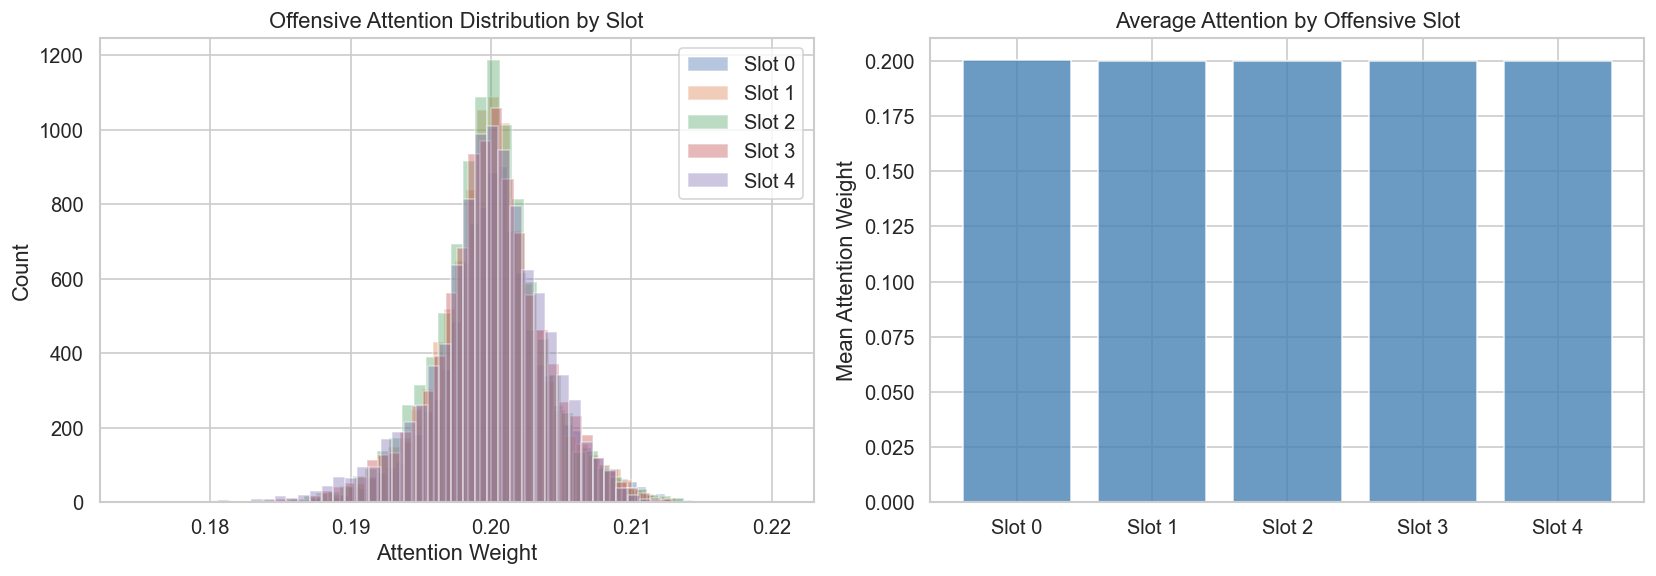

Mean attention per slot: [0.2004 0.2    0.1998 0.2    0.1999]
Attention entropy: 1.6092 (uniform=1.6094)


In [14]:
@torch.no_grad()
def get_full_attention(players_10, state_3):
    """Get both offensive and defensive attention weights."""
    pl = torch.tensor(players_10, dtype=torch.long, device=device).unsqueeze(0)
    st = torch.tensor(state_3, dtype=torch.float32, device=device).unsqueeze(0)
    tm = TEAM_IDS.unsqueeze(0)
    tok = model._embed_players(pl, tm)
    h = model.encoder(tok)
    _, off_attn = model.attn_pool_off(h[:, :5, :])
    _, def_attn = model.attn_pool_def(h[:, 5:, :])
    return off_attn.squeeze(0).cpu().numpy(), def_attn.squeeze(0).cpu().numpy()

# Analyze attention patterns for specific notable lineups
# Use actual lineups from test data that contain superstars
print("Attention profiles for notable lineups:\n")

for dname, bbref, season, target_ps, count in notable_found[:6]:
    # Find a real lineup with this player
    poss_list = offense_index.get(target_ps, [])
    if not poss_list:
        continue
    poss_idx, slot = poss_list[0]  # first possession
    players = test_ds.players[poss_idx]
    state = test_ds.state[poss_idx]

    off_attn, def_attn = get_full_attention(players, state)
    off_names = [id_to_name.get(int(p), "?")[:25] for p in players[:5]]
    def_names = [id_to_name.get(int(p), "?")[:25] for p in players[5:]]

    print(f"{'='*60}")
    print(f"  {dname} ({season}) — lineup example")
    print(f"  Offense:")
    for i, (name, w) in enumerate(zip(off_names, off_attn)):
        bar = '#' * int(w * 50)
        marker = ' <-- STAR' if int(players[i]) == target_ps else ''
        print(f"    {name:25s} {w:.3f} {bar}{marker}")
    print(f"  Defense:")
    for i, (name, w) in enumerate(zip(def_names, def_attn)):
        bar = '#' * int(w * 50)
        print(f"    {name:25s} {w:.3f} {bar}")
    print()

# Aggregate: average attention to each slot across many possessions
N_ATT = min(10000, len(test_ds))
att_indices = np.random.choice(len(test_ds), N_ATT, replace=False)

all_off_attn = []
BS = 512
for start in tqdm(range(0, N_ATT, BS), desc="Aggregate attention"):
    end = min(start + BS, N_ATT)
    idx = att_indices[start:end]
    pl = torch.tensor(test_ds.players[idx], dtype=torch.long, device=device)
    st = torch.tensor(test_ds.state[idx], dtype=torch.float32, device=device)
    B = pl.shape[0]
    tm = TEAM_IDS.unsqueeze(0).expand(B, -1)
    with torch.no_grad():
        _, off_attn_batch = model.forward_finetune(pl, st, tm)
    all_off_attn.append(off_attn_batch.cpu().numpy())

agg_off_attn = np.concatenate(all_off_attn, axis=0)  # [N, 5]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution per slot
for slot in range(5):
    axes[0].hist(agg_off_attn[:, slot], bins=50, alpha=0.4, label=f"Slot {slot}")
axes[0].set_xlabel("Attention Weight")
axes[0].set_ylabel("Count")
axes[0].set_title("Offensive Attention Distribution by Slot")
axes[0].legend()

# Mean attention per slot
mean_attn = agg_off_attn.mean(axis=0)
axes[1].bar(range(5), mean_attn, color="steelblue", alpha=0.8)
axes[1].set_xticks(range(5))
axes[1].set_xticklabels([f"Slot {i}" for i in range(5)])
axes[1].set_ylabel("Mean Attention Weight")
axes[1].set_title("Average Attention by Offensive Slot")

plt.tight_layout()
plt.show()

print(f"Mean attention per slot: {mean_attn.round(4)}")
print(f"Attention entropy: {-(agg_off_attn * np.log(agg_off_attn + 1e-10)).sum(axis=1).mean():.4f} "
      f"(uniform={-5*0.2*np.log(0.2):.4f})")

## Section 7: Role Versatility Detection

Which players' contextual representations change the most across different lineups? Players with high variance are "chameleons" who adapt their role to context. Players with low variance play the same role regardless of teammates.

**Two complementary metrics:**
1. **Representation variance** (1 - mean cosine similarity to centroid): Raw measure of how much the contextual token moves. Volume-weighted to avoid noise from low-sample players.
2. **Archetype boundary crossing**: How often a player's contextual token lands in a *different* archetype cluster than their static embedding's cluster. More robust and interpretable than raw variance — e.g., "Draymond Green plays like a wing in some lineups and a center in others."

Players with >= 50 offensive possessions in test data: 1594


Versatility analysis:   0%|          | 0/1594 [00:00<?, ?it/s]


TOP 20 — Most versatile (role changes with context):
Player                                  N  Versatility  Crossing%  Arch
--------------------------------------------------------------------------------
Dewayne Dedmon (2021)                 200      0.62112      70.0%     4
George Hill (2021)                    200      0.61741      92.5%     3
Cedi Osman (2021)                     200      0.61126      64.0%     6
Collin Sexton (2021)                  200      0.60550      96.0%     1
Avery Bradley (2021)                  200      0.60510      76.0%     6
Wesley Matthews (2021)                200      0.60446      62.0%     0
Daniel Theis (2021)                   200      0.60411      83.0%     4
Al Horford (2021)                     200      0.60362      79.5%     4
Damion Lee (2021)                     200      0.60237      96.5%     1
Draymond Green (2021)                 200      0.60139      47.0%     0
LeBron James (2021)                   200      0.60126      90.0%     3
J

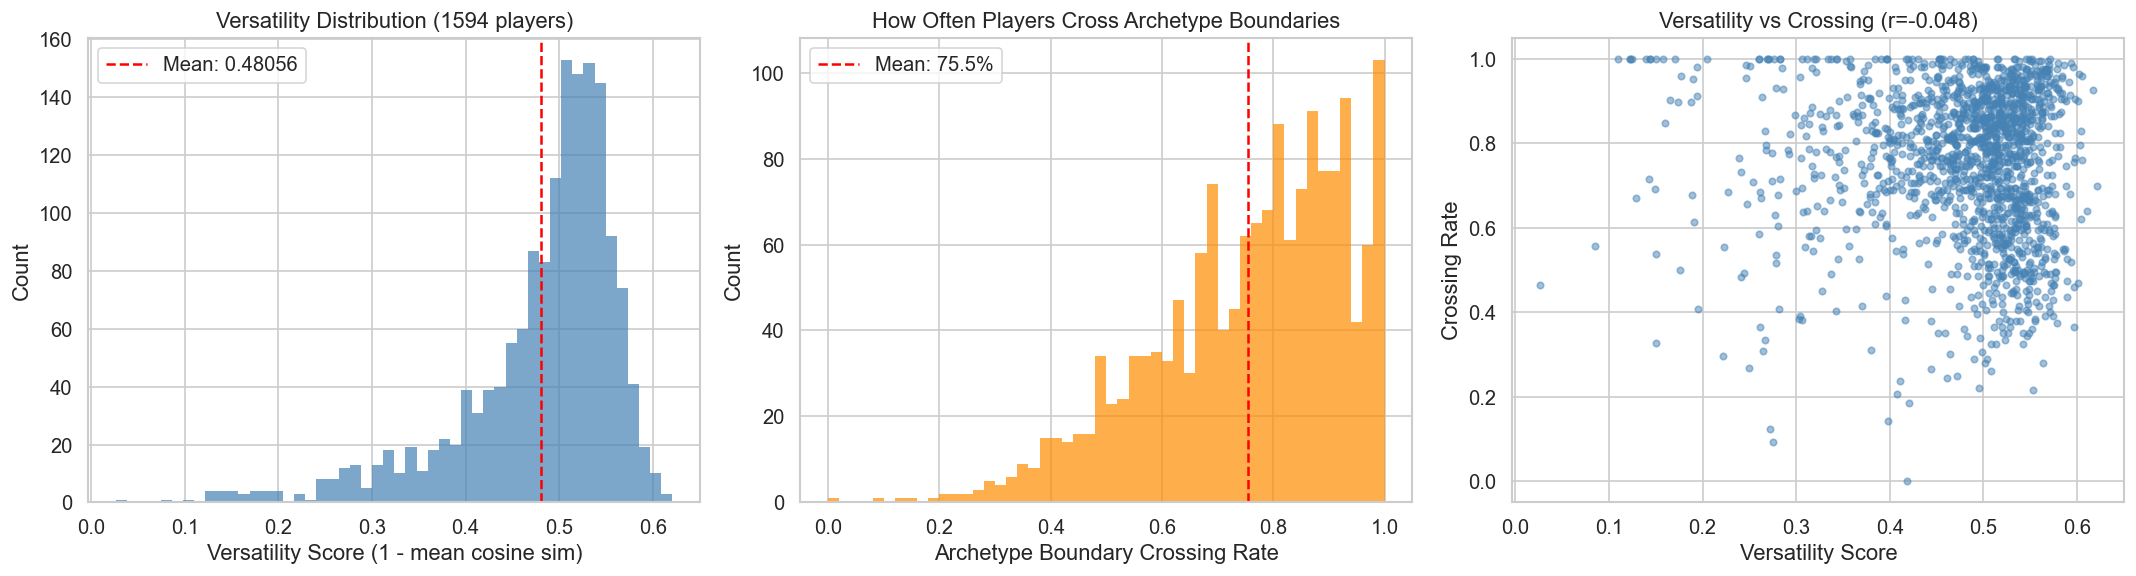

In [15]:
# For each player-season with enough test possessions, collect their
# contextual representation (encoder output token) across different lineups
# and measure variance + archetype boundary crossing.

MIN_LINEUPS = 50  # need at least this many distinct lineups

# Find player-seasons with enough offensive appearances
eligible = [(ps, poss_list) for ps, poss_list in offense_index.items()
            if len(poss_list) >= MIN_LINEUPS and id_to_season.get(ps, 0) >= 2021]
print(f"Players with >= {MIN_LINEUPS} offensive possessions in test data: {len(eligible)}")

# Precompute archetype cluster centroids in encoder output space for boundary crossing
# We'll assign contextual tokens to the nearest archetype centroid
km_centroids = torch.tensor(km.cluster_centers_, dtype=torch.float32)  # [8, 384] in base_emb space

versatility_results = []
MAX_SAMPLE = 200  # max lineups per player for efficiency

for target_ps, poss_list in tqdm(eligible, desc="Versatility analysis"):
    # Sample lineups
    sample = poss_list[:MAX_SAMPLE] if len(poss_list) <= MAX_SAMPLE else \
             [poss_list[i] for i in np.random.choice(len(poss_list), MAX_SAMPLE, replace=False)]

    indices = [idx for idx, slot in sample]
    slots = [slot for idx, slot in sample]

    players_batch = test_ds.players[indices]
    states_batch = test_ds.state[indices]

    # Get encoder outputs
    pl = torch.tensor(players_batch, dtype=torch.long, device=device)
    st = torch.tensor(states_batch, dtype=torch.float32, device=device)
    B = pl.shape[0]
    tm = TEAM_IDS.unsqueeze(0).expand(B, -1).to(device)

    with torch.no_grad():
        tok = model._embed_players(pl, tm)
        h = model.encoder(tok)  # [B, 10, d_model]

    # Extract the target player's token from each lineup
    contextual_reps = []
    for i, slot in enumerate(slots):
        contextual_reps.append(h[i, slot, :].cpu())

    contextual_reps = torch.stack(contextual_reps)  # [N, d_model]
    contextual_reps_norm = F.normalize(contextual_reps, dim=1)

    # Metric 1: Versatility = 1 - mean pairwise cosine similarity
    mean_rep = contextual_reps_norm.mean(dim=0)
    mean_cos = (contextual_reps_norm @ mean_rep).mean().item()
    versatility = 1.0 - mean_cos

    # Metric 2: Archetype boundary crossing
    # What archetype is this player's static embedding?
    target_base = ps_to_base_map.get(target_ps)
    if target_base is not None and target_base < num_base:
        static_archetype = archetype_labels[target_base]
        # Assign each contextual token to nearest archetype centroid
        # Use cosine similarity to cluster centroids
        ctx_norm = F.normalize(contextual_reps, dim=1)
        cent_norm = F.normalize(km_centroids, dim=1)
        sims = ctx_norm @ cent_norm.T  # [N, 8]
        contextual_archetypes = sims.argmax(dim=1).numpy()  # [N]
        # Boundary crossing rate = fraction of lineups where contextual archetype != static archetype
        crossing_rate = (contextual_archetypes != static_archetype).mean()
    else:
        crossing_rate = float('nan')
        static_archetype = -1

    # Also compute std of norms
    norm_std = contextual_reps.norm(dim=1).std().item()

    versatility_results.append({
        "ps_id": target_ps,
        "name": id_to_name.get(target_ps, str(target_ps)),
        "n_lineups": len(sample),
        "versatility": versatility,
        "crossing_rate": crossing_rate,
        "static_archetype": static_archetype,
        "norm_std": norm_std,
    })

# Sort by versatility (volume-weighted: only players with 50+ lineups are included)
versatility_results.sort(key=lambda x: x["versatility"], reverse=True)

# Display top and bottom
print("\n" + "="*80)
print("TOP 20 — Most versatile (role changes with context):")
print(f"{'Player':<35s} {'N':>5s} {'Versatility':>12s} {'Crossing%':>10s} {'Arch':>5s}")
print("-"*80)
for r in versatility_results[:20]:
    cr = f"{r['crossing_rate']*100:.1f}%" if not np.isnan(r['crossing_rate']) else "N/A"
    print(f"{r['name']:<35s} {r['n_lineups']:>5d} {r['versatility']:>12.5f} {cr:>10s} {r['static_archetype']:>5d}")

print(f"\nBOTTOM 20 — Most rigid (same role regardless of context):")
print(f"{'Player':<35s} {'N':>5s} {'Versatility':>12s} {'Crossing%':>10s} {'Arch':>5s}")
print("-"*80)
for r in versatility_results[-20:]:
    cr = f"{r['crossing_rate']*100:.1f}%" if not np.isnan(r['crossing_rate']) else "N/A"
    print(f"{r['name']:<35s} {r['n_lineups']:>5d} {r['versatility']:>12.5f} {cr:>10s} {r['static_archetype']:>5d}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram of versatility
vers = [r["versatility"] for r in versatility_results]
axes[0].hist(vers, bins=50, alpha=0.7, color="steelblue", edgecolor="none")
axes[0].axvline(np.mean(vers), color="red", linestyle="--", label=f"Mean: {np.mean(vers):.5f}")
axes[0].set_xlabel("Versatility Score (1 - mean cosine sim)")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Versatility Distribution ({len(versatility_results)} players)")
axes[0].legend()

# Histogram of crossing rate
cross = [r["crossing_rate"] for r in versatility_results if not np.isnan(r["crossing_rate"])]
axes[1].hist(cross, bins=50, alpha=0.7, color="darkorange", edgecolor="none")
axes[1].axvline(np.mean(cross), color="red", linestyle="--", label=f"Mean: {np.mean(cross):.1%}")
axes[1].set_xlabel("Archetype Boundary Crossing Rate")
axes[1].set_ylabel("Count")
axes[1].set_title("How Often Players Cross Archetype Boundaries")
axes[1].legend()

# Scatter: versatility vs crossing rate
valid = [(r["versatility"], r["crossing_rate"]) for r in versatility_results
         if not np.isnan(r["crossing_rate"])]
if valid:
    v, c = zip(*valid)
    axes[2].scatter(v, c, s=15, alpha=0.5, color="steelblue")
    corr = np.corrcoef(v, c)[0, 1]
    axes[2].set_xlabel("Versatility Score")
    axes[2].set_ylabel("Crossing Rate")
    axes[2].set_title(f"Versatility vs Crossing (r={corr:.3f})")

plt.tight_layout()
plt.show()

## Section 8: Aging Curves & Skill Evolution

How does player identity change with age? The delta embeddings capture season-specific deviation from a player's base archetype. Aggregating delta magnitudes by player age reveals macro patterns: do players change most during development (early 20s) or decline (mid 30s)?

This analysis uses **static embeddings** — delta norms from checkpoint weights — but provides insights unique to the player-season embedding design.

Delta norms: shape=(12821,), mean=0.1697, std=0.1108, max=0.3000


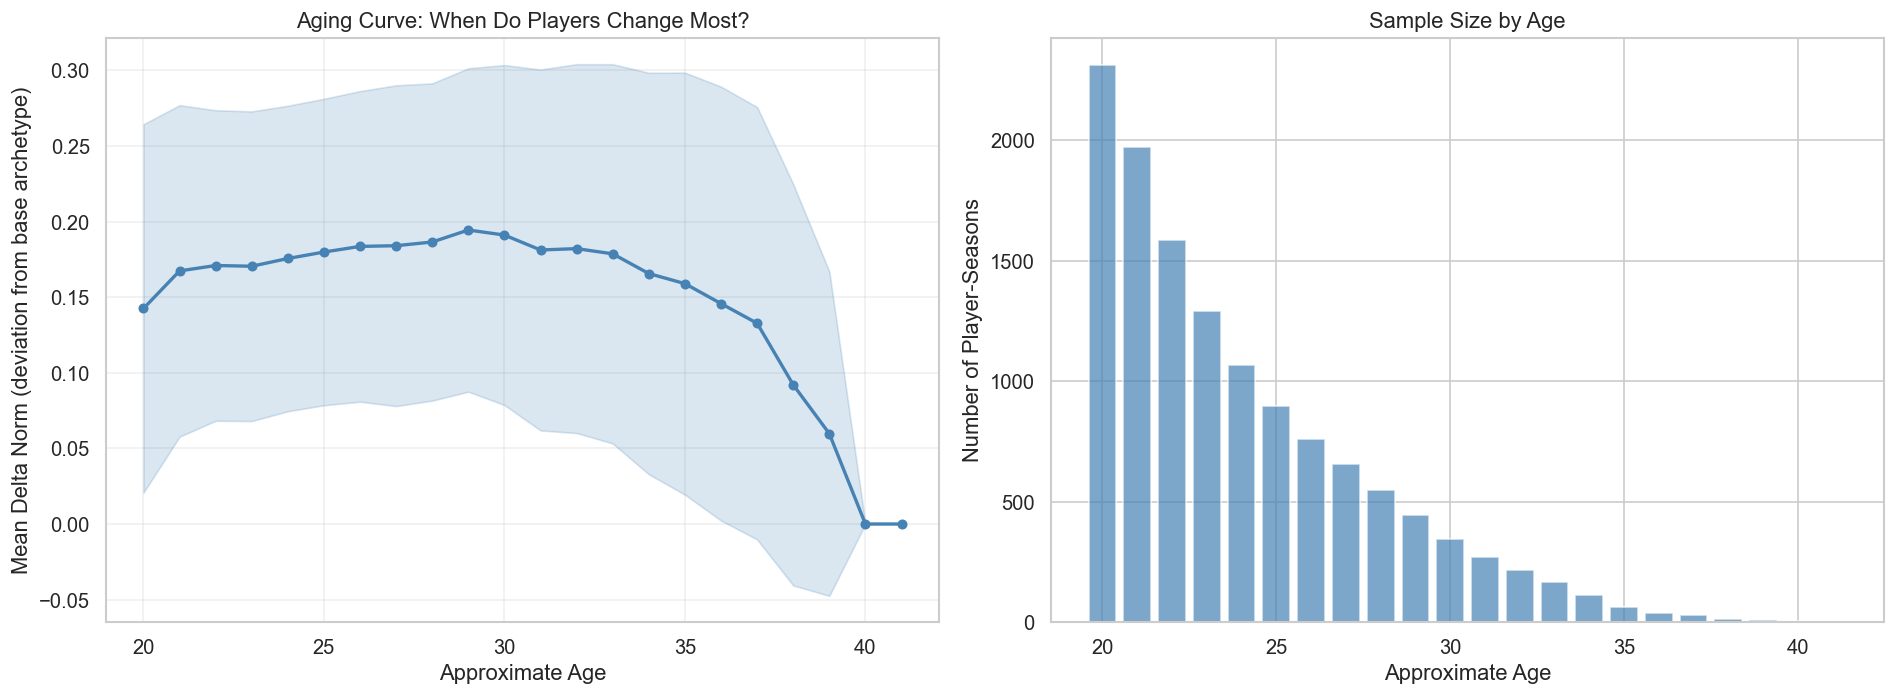


 Age      N   Mean Delta        Std
-----------------------------------
  20   2311       0.1426     0.1218
  21   1971       0.1674     0.1096
  22   1587       0.1710     0.1027
  23   1293       0.1705     0.1024
  24   1069       0.1756     0.1010
  25    898       0.1799     0.1013
  26    762       0.1836     0.1027
  27    656       0.1841     0.1061
  28    551       0.1865     0.1049
  29    445       0.1945     0.1069
  30    348       0.1911     0.1124
  31    272       0.1812     0.1194
  32    217       0.1821     0.1220
  33    167       0.1787     0.1254
  34    112       0.1656     0.1328
  35     63       0.1590     0.1396
  36     41       0.1458     0.1435
  37     30       0.1328     0.1430


In [16]:
# --- Aging Curves: Delta magnitude by player age ---
# The delta embedding captures season-specific deviation from the base player archetype.
# Larger delta = more the player's role/style deviated that season from their career norm.

# Extract delta norms for all player-seasons
with torch.no_grad():
    if hasattr(model, 'delta_proj'):
        # v3.2 bottleneck: delta_raw [12821, 64] -> delta_proj [64, 384]
        delta_raw_w = model.delta_raw.weight  # [12821, delta_dim]
        delta_projected = delta_raw_w @ model.delta_proj.weight.T  # [12821, 384]
        delta_norms = delta_projected.norm(dim=1).cpu().numpy()
    else:
        delta_norms = model.delta_emb.weight.norm(dim=1).cpu().numpy()

print(f"Delta norms: shape={delta_norms.shape}, mean={delta_norms.mean():.4f}, "
      f"std={delta_norms.std():.4f}, max={delta_norms.max():.4f}")

# We need player birth years / draft years to compute age.
# Approximate from career span: rookie season ≈ age 19-20.
# For each base player, find their earliest season and assume they were ~20 then.

player_first_season = {}
player_seasons_data = []

for _, row in lu.iterrows():
    bbref = row["player"]
    season = int(row["season"])
    ps = int(row["player_season_id"])
    
    if bbref not in player_first_season or season < player_first_season[bbref]:
        player_first_season[bbref] = season
    
    delta_norm = delta_norms[ps] if ps < len(delta_norms) else 0.0
    player_seasons_data.append({
        "bbref": bbref,
        "season": season,
        "ps_id": ps,
        "delta_norm": delta_norm,
    })

# Compute approximate age (years since first season + 20)
age_delta_pairs = []
for entry in player_seasons_data:
    first = player_first_season[entry["bbref"]]
    approx_age = 20 + (entry["season"] - first)
    if 19 <= approx_age <= 42:  # filter reasonable ages
        age_delta_pairs.append((approx_age, entry["delta_norm"], entry["bbref"]))

ages = np.array([a for a, d, _ in age_delta_pairs])
deltas = np.array([d for a, d, _ in age_delta_pairs])

# Aggregate by age
age_groups = defaultdict(list)
for age, delta, _ in age_delta_pairs:
    age_groups[age].append(delta)

age_sorted = sorted(age_groups.keys())
mean_deltas = [np.mean(age_groups[a]) for a in age_sorted]
std_deltas = [np.std(age_groups[a]) for a in age_sorted]
counts = [len(age_groups[a]) for a in age_sorted]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Aging curve: mean delta norm by age
axes[0].plot(age_sorted, mean_deltas, 'o-', color='steelblue', linewidth=2, markersize=5)
axes[0].fill_between(age_sorted,
                      [m - s for m, s in zip(mean_deltas, std_deltas)],
                      [m + s for m, s in zip(mean_deltas, std_deltas)],
                      alpha=0.2, color='steelblue')
axes[0].set_xlabel("Approximate Age")
axes[0].set_ylabel("Mean Delta Norm (deviation from base archetype)")
axes[0].set_title("Aging Curve: When Do Players Change Most?")
axes[0].grid(True, alpha=0.3)

# Sample size per age
axes[1].bar(age_sorted, counts, color='steelblue', alpha=0.7)
axes[1].set_xlabel("Approximate Age")
axes[1].set_ylabel("Number of Player-Seasons")
axes[1].set_title("Sample Size by Age")

plt.tight_layout()
plt.show()

# Print summary
print(f"\n{'Age':>4s} {'N':>6s} {'Mean Delta':>12s} {'Std':>10s}")
print("-" * 35)
for age, mean, std, n in zip(age_sorted, mean_deltas, std_deltas, counts):
    if n >= 20:  # only show ages with enough data
        print(f"{age:>4d} {n:>6d} {mean:>12.4f} {std:>10.4f}")

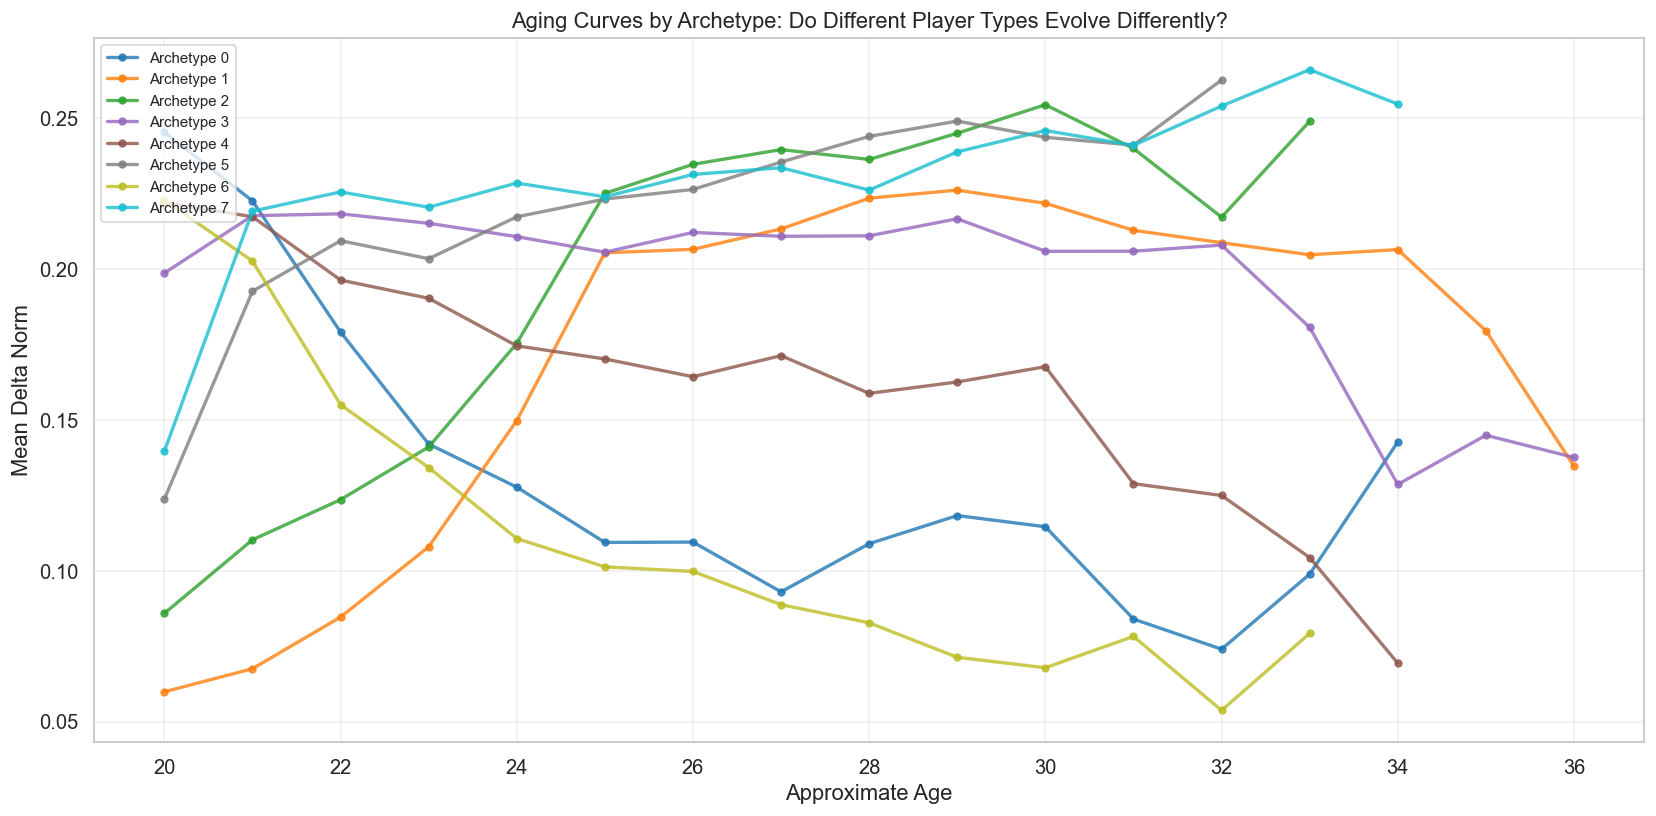

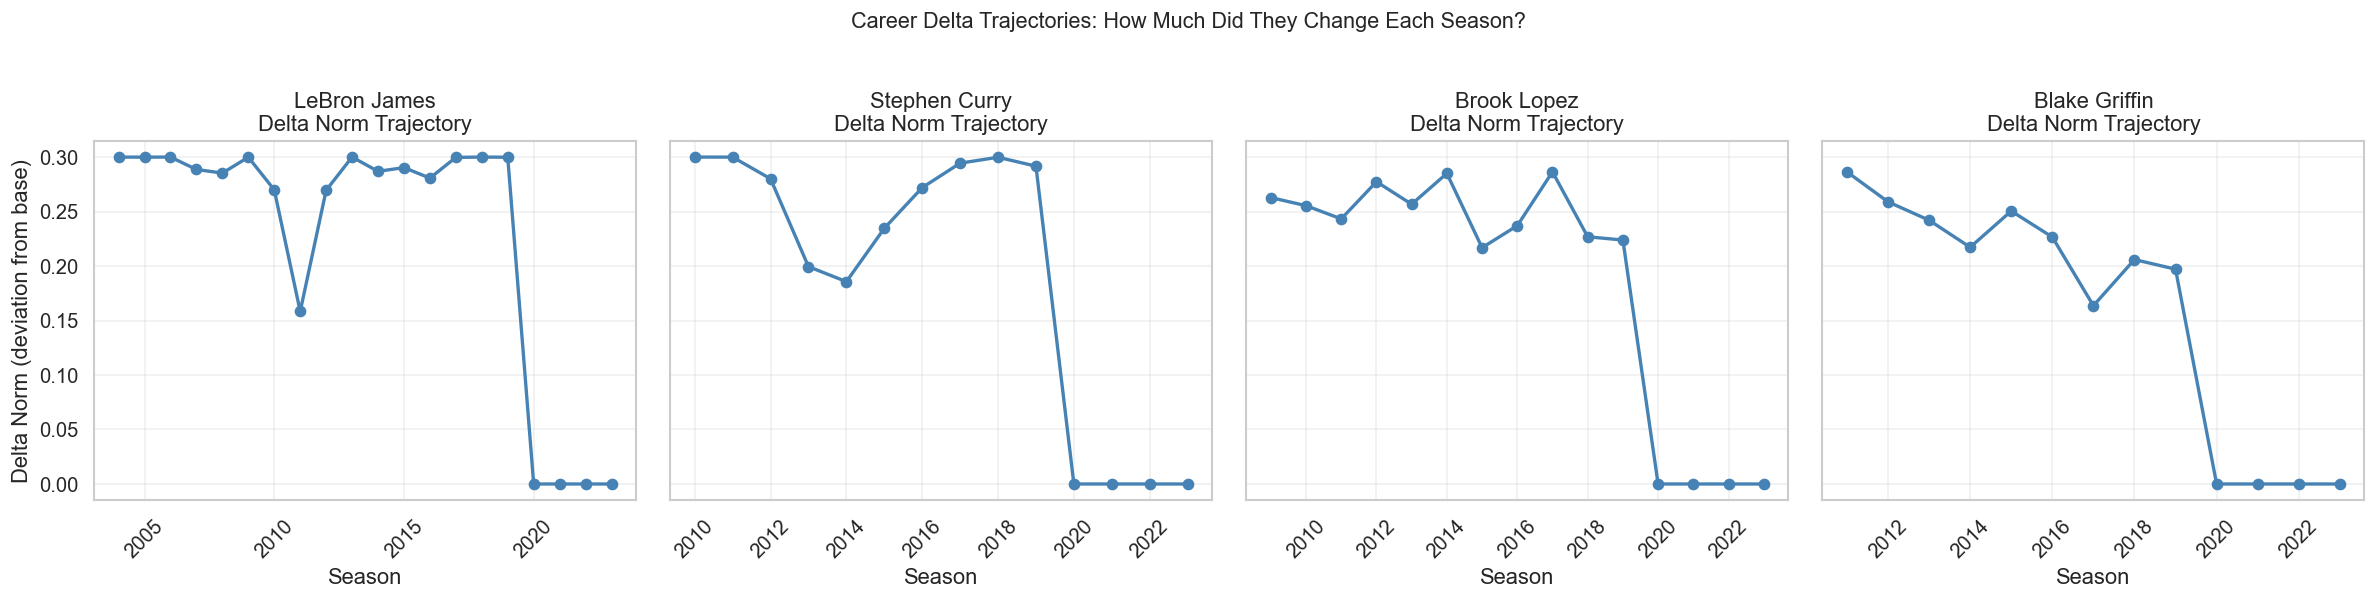

In [17]:
# --- Aging curves segmented by archetype ---
# Do different player types evolve differently?

archetype_age_data = defaultdict(lambda: defaultdict(list))  # arch -> age -> [delta_norms]
for entry in player_seasons_data:
    ps = entry["ps_id"]
    base = ps_to_base_map.get(ps)
    if base is None or base >= num_base:
        continue
    arch = archetype_labels[base]
    first = player_first_season[entry["bbref"]]
    approx_age = 20 + (entry["season"] - first)
    if 20 <= approx_age <= 38:
        archetype_age_data[arch][approx_age].append(entry["delta_norm"])

fig, ax = plt.subplots(figsize=(14, 7))
colors_arch = plt.cm.tab10(np.linspace(0, 1, 8))

for arch in range(8):
    age_data = archetype_age_data[arch]
    ages_a = sorted([a for a in age_data if len(age_data[a]) >= 10])
    if len(ages_a) < 5:
        continue
    means = [np.mean(age_data[a]) for a in ages_a]
    ax.plot(ages_a, means, 'o-', color=colors_arch[arch], linewidth=2,
            markersize=4, label=f"Archetype {arch}", alpha=0.8)

ax.set_xlabel("Approximate Age")
ax.set_ylabel("Mean Delta Norm")
ax.set_title("Aging Curves by Archetype: Do Different Player Types Evolve Differently?")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Highlight specific career trajectories for compelling stories
highlight_players = [
    ("jamesle01", "LeBron James"),
    ("curryst01", "Stephen Curry"),
    ("lopezbr01", "Brook Lopez"),
    ("griffbl01", "Blake Griffin"),
]

fig, axes = plt.subplots(1, len(highlight_players), figsize=(5*len(highlight_players), 5), sharey=True)
if len(highlight_players) == 1:
    axes = [axes]

for i, (bbref, dname) in enumerate(highlight_players):
    ax = axes[i]
    seasons = []
    norms = []
    for entry in player_seasons_data:
        if entry["bbref"] == bbref:
            seasons.append(entry["season"])
            norms.append(entry["delta_norm"])
    if seasons:
        order = np.argsort(seasons)
        seasons = [seasons[j] for j in order]
        norms = [norms[j] for j in order]
        ax.plot(seasons, norms, 'o-', color='steelblue', linewidth=2, markersize=6)
        ax.set_xlabel("Season")
        ax.set_title(f"{dname}\nDelta Norm Trajectory")
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Delta Norm (deviation from base)")
plt.suptitle("Career Delta Trajectories: How Much Did They Change Each Season?", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()